BH — Buy & Hold (baseline)

Intent: Benchmark. “Do nothing” after initial buys.

Cash model: Per-symbol (no pooling).

Buys: On a symbol’s first day, invest a fixed amount; then just hold.

Sells: None.

Allocation signal: Ignores pos_frac/score.

Metrics to watch: Daily equal-weight BH return, cumulative BH curve. Realized% is not used (no decisions after day 1).

S2 — Sequestered accounts (one mini-portfolio per symbol)

Intent: Respect signals without cross-subsidizing symbols.

Cash model: Per-symbol cash account (no pooling).

Buys: Spend pos_frac × symbol_cash.

Sells: Fractional—sell pos_frac × shares; proceeds stay with that symbol.

Allocation signal: pos_frac only (ignores score by default).

Notes: Great sandbox to understand raw signal behavior per name.

S3 — Pooling baseline (fractional sells; pooled cash)

Intent: One pot of cash; gentle rebalancing via fractional sells.

Cash model: Pooled across symbols.

Buys: Allocate pool ∝ pos_frac across BUYs.

Sells: Fractional (reduce position by pos_frac); proceeds to the pool.

Allocation signal: pos_frac only (no confidence weighting).

S4 — Flatten-on-SELL (pooled cash)

Intent: S3 behavior but faster de-risking on SELL.

Cash model: Pooled.

Buys: Allocate pool ∝ pos_frac.

Sells: Flatten (exit 100%) on SELL.

Allocation signal: pos_frac only.

S5 — Weighted & flatten (pooled cash + confidence weighting)

Intent: Favor higher-confidence names when buying; still flatten on SELL.

Cash model: Pooled.

Buys: Allocate pool ∝ pos_frac × dyn_weight(score).

Sells: Flatten on SELL.

Allocation signal: pos_frac and score (mapped to ~0.5–1.5× weight).

Notes: If score is missing, falls back to equal weight within BUYs.

S6 — Budgeted, evidence-weighted (fractional sells; pooled cash)

Intent: Use signal size and evidence strength; don’t always flatten.

Cash model: Pooled.

Buys: Allocate ∝ pos_frac × evidence_weight, then clamp per-row fraction (e.g., [0.00–0.50]) before normalizing.

Sells: Fractional (respect pos_frac).

Allocation signal: pos_frac, score→weight, and sample-size ramp toward full weight as n_seen grows.

Notes: More conservative via budget clamps; smoother turnover.

S7 — Budgeted, evidence-weighted with flatten (pooled cash)

Intent: S6 buy logic + decisive exits.

Cash model: Pooled.

Buys: Same as S6 (evidence-weighted with clamps).

Sells: Flatten on SELL.

Allocation signal: pos_frac, score, sample-size ramp, clamps.

S8 — “Only Winners” gate (pooled, flatten sells, eligibility filter)

Intent: Trade only symbols that have proven themselves so far.

Eligibility: A symbol is tradable today only if its prior-day cumulative realized TWR ≥ 0 (use a tiny epsilon for float noise).

Cash model: Pooled.

Buys: Allocate pool ∝ pos_frac × dyn_weight(score) but mask to 0 if ineligible.

Sells: Flatten on SELL.

Allocation signal: pos_frac, score (0.5–1.5×), eligibility mask.

Variants: Optional Bayesian accuracy multiplier before clamping.

S9 — “Only Recent Winners” (new; like S8 but rolling 10)

Intent: Trade names with recent proof, not lifetime.

Eligibility: Tradable today only if the rolling last-10 inferences realized TWR > 0 (computed per symbol, shifted so it uses only prior info).

Cash model: Pooled.

Buys: Allocate pool ∝ pos_frac × dyn_weight(score) masked by S9 eligibility.

Sells: Flatten on SELL.

Allocation signal: pos_frac, score (0.5–1.5×), rolling-10 eligibility mask.

Why it exists: Catches momentum/regime shifts faster than S8’s all-history gate.

In [306]:
# EDIT THIS: symbols you want to include in the "select" slice
SELECT_SYMBOLS = ["NVDA",'QS','SLDP','GOOGL','MSFT'
 #,'BYND',
 
 "AAPL", 'AEP', 'AI', 'ALB', 'AMD', 'AMSC', 'ARQQ', 'ARRY', 'BHP',  'CHGG', 'CLNE', 'COST', 'ELVA', 
 'ENPH', 'ENVX', 'EOSE', 'EVGO', 'FLNC', 'FSLR' 
 ,'GEVO', 'GOOGL', 'IBM', 'INFA', 'INTC', 'IONQ', 'ITRI', 
 'LCID', 'MDB', 'MNTK', 'MRK', 'MSFT', 'MU', 'MVST', 'NFLX', 
 'NVDA', 'NVTS', 'NXT', 'PAYO', 'PG', 'PGR', 'PLUG', 'POWI', 'PSTG', 'QBTS', 'QS', 'QUBT', 'RGTI', 
 'RMBS', 'RNW', 'ROP', 'SEDG', 'SLDP', 'SMCI', 'SNOW', 'TDC', 'TM', 'TRV', 'TSM', 'VICR', 'VZ', 'XEL'
]

In [307]:
# --- Patched Cell A: discover & classify (skip aggregates) ---
from pathlib import Path
import re
import pandas as pd

LOGS_DIR = Path(".")  # notebook is in ./logs

SKIP_RE = re.compile(r"(^_|combined|history|normalized)", re.IGNORECASE)
csvs = sorted(p for p in LOGS_DIR.glob("*.csv") if not SKIP_RE.search(p.name))

def read_header(path: Path):
    try:
        return pd.read_csv(path, nrows=0, sep=None, engine="python", encoding="utf-8-sig").columns.str.lower().tolist()
    except Exception:
        return []

def classify(cols):
    c = set(cols)
    # Explicitly mark known aggregate outputs if they sneak through
    if {"source_file","schema_version","src_kind"} <= c:
        return "aggregate_output"

    # Sept live snapshot (your example)
    if {"timestamp_utc","symbol","price_3pm","signal","pos_frac","qty","bias","buf_scale","mid","upper","lower"} <= c:
        return "sept_live_snapshot"

    # Stabilized infer (Oct+)
    if "symbol" in c and (("sig" in c) or ("signal" in c) or ("side" in c)) and {"mid","upper","lower"} <= c:
        return "stable_infer"

    # Generic banded logs
    if {"symbol","mid","upper","lower"} <= c:
        return "generic_banded"

    return "unknown"

catalog = []
for p in csvs:
    cols = read_header(p)
    kind = classify(cols)
    if kind not in {"unknown", "aggregate_output"}:
        catalog.append((p, kind, cols))

print(f"Found {len(catalog)} usable CSVs in {LOGS_DIR.resolve()}")
for p, kind, cols in catalog[:10]:
    print(f"  - {p.name:30s}  [{kind}]  cols={len(cols)}")


Found 49 usable CSVs in C:\Users\brobi\OneDrive\Desktop\Algo1\logs
  - infer_2025-09-15.csv            [sept_live_snapshot]  cols=11
  - infer_2025-09-16.csv            [sept_live_snapshot]  cols=11
  - infer_2025-09-18.csv            [sept_live_snapshot]  cols=11
  - infer_2025-09-19.csv            [sept_live_snapshot]  cols=11
  - infer_2025-09-22.csv            [stable_infer]  cols=13
  - infer_2025-09-23.csv            [stable_infer]  cols=13
  - infer_2025-09-24.csv            [stable_infer]  cols=13
  - infer_2025-09-25.csv            [stable_infer]  cols=13
  - infer_2025-09-26.csv            [stable_infer]  cols=13
  - infer_2025-09-29.csv            [stable_infer]  cols=13


In [308]:
# --- Patch: show date range across infer files ---
import pandas as pd
import re

def _pick_time_col(cols):
    # prefer explicit names; then fall back to any col containing 'time' or 'date'
    pref = ["timestamp_utc", "timestamp_et", "timestamp", "as_of", "date"]
    cset = set(cols)
    for k in pref:
        if k in cset:
            return k
    cands = [c for c in cols if re.search(r"(time|date)", c)]
    return cands[0] if cands else None

overall_min = None
overall_max = None
files_used  = 0

for p, kind, cols in catalog:
    tcol = _pick_time_col(cols)
    if not tcol:
        continue
    try:
        # read only the time column (case-insensitive)
        s = pd.read_csv(
            p,
            usecols=lambda c: c.strip().lower() == tcol,
            encoding="utf-8-sig"
        )
        # normalize column name to lower so we can reference tcol directly
        s.columns = s.columns.str.strip().str.lower()
        dt = pd.to_datetime(s[tcol], errors="coerce")
        if dt.notna().any():
            fmin, fmax = dt.min(), dt.max()
            overall_min = fmin if overall_min is None else min(overall_min, fmin)
            overall_max = fmax if overall_max is None else max(overall_max, fmax)
            files_used += 1
    except Exception:
        pass  # skip unreadable files silently; they're already filtered by catalog

if overall_min is not None:
    print(f"Date range across {files_used}/{len(catalog)} infer files: {overall_min} → {overall_max}")
else:
    print("Date range: unavailable (no recognizable time/date column found).")


Date range across 49/49 infer files: 2025-09-16 01:16:12+00:00 → 2025-11-22 16:10:05+00:00


In [309]:
# --- Cell B: loader & normalizer for all recognized variants (UPDATED) ---
from pathlib import Path
import numpy as np
import re
import pandas as pd

BASE_COLS = [
    "timestamp_utc","symbol","date","price","bias",
    "buf_scale","pos_frac","pre_sig","sig","side",
    "mid","upper","lower","buf"
]

# Map many historical names → unified schema
RENAME_MAP = {
    # date/time
    "date_bar":"date","bar_date":"date","date_iso":"date","day":"date",
    "timestamp":"timestamp_utc","time_utc":"timestamp_utc","ts_utc":"timestamp_utc","ts":"timestamp_utc",
    # price fields
    "close":"price","last":"price","last_price":"price",
    "price_3pm":"price","price_cutoff":"price","price_live":"price",
    # bands
    "m":"mid","u":"upper","l":"lower",
    # policy / signals
    "policy":"bias","regime":"bias",
    "pre_signal":"pre_sig","presig":"pre_sig",
    "signal":"sig","signal_final":"sig",
    "action":"side","sig_text":"side",
}

def _normalize_colnames(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    overlap = set(RENAME_MAP) & set(df.columns)
    if overlap:
        df = df.rename(columns={k: RENAME_MAP[k] for k in overlap})
    return df

def _map_side_to_text(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().upper()
    # common string variants
    if s in {"BUY", "B", "LONG", "+1", "1"}:
        return "BUY"
    if s in {"SELL", "S", "SHORT", "0"}:
        return "SELL"
    if s in {"HOLD", "H", "NEUTRAL", "FLAT", "-1"}:
        return "HOLD"
    # last-ditch numeric parse
    try:
        i = int(float(s))
        return {1: "BUY", 0: "SELL", -1: "HOLD"}.get(i, np.nan)
    except Exception:
        return np.nan

def _infer_date_from_filename(name: str):
    m1 = re.search(r"(\d{4}-\d{2}-\d{2})", name)   # 2025-09-19
    m2 = re.search(r"(\d{8})", name)               # 20250919
    if m1: return pd.to_datetime(m1.group(1)).date()
    if m2: return pd.to_datetime(m2.group(1), format="%Y%m%d").date()
    return None

def read_csv_lenient(path):
    return pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")

def standardize_file(path: Path, src_kind: str) -> pd.DataFrame:
    df = read_csv_lenient(path)
    if df.empty:
        return df

    df = _normalize_colnames(df)
    df["source_file"]   = path.name
    df["src_kind"]      = src_kind
    df["log_file_date"] = _infer_date_from_filename(path.name)

    # Canonicalize symbol
    if "symbol" in df.columns:
        df["symbol"] = df["symbol"].astype(str).str.upper().str.strip()

    # If we have timestamp in ET but no UTC, convert → UTC
    if "timestamp_utc" not in df.columns and "timestamp_et" in df.columns:
        ts_et = pd.to_datetime(df["timestamp_et"], errors="coerce")
        try:
            dt_et = ts_et.dt.tz_localize("America/New_York", nonexistent="shift_forward", ambiguous="NaT")
        except TypeError:
            dt_et = ts_et.dt.tz_localize("US/Eastern", nonexistent="shift_forward", ambiguous="NaT")
        df["timestamp_utc"] = dt_et.dt.tz_convert("UTC")

    # Ensure timestamp_utc is datetime with UTC
    if "timestamp_utc" in df.columns:
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], errors="coerce", utc=True)

    # --- Derive/normalize date (fills partial nulls too) ---
    ts_utc = df["timestamp_utc"] if "timestamp_utc" in df.columns else None
    if "date" not in df.columns:
        if ts_utc is not None:
            df["date"] = pd.to_datetime(ts_utc, errors="coerce").dt.date
        else:
            df["date"] = df["log_file_date"]
    else:
        d0 = pd.to_datetime(df["date"], errors="coerce").dt.date
        if ts_utc is not None:
            d1 = pd.to_datetime(ts_utc, errors="coerce").dt.date
            df["date"] = np.where(pd.isna(d0), d1, d0)
        else:
            df["date"] = np.where(pd.isna(d0), df["log_file_date"], d0)

    # --- Side normalization (handles side/sig/signal as text or numbers) ---
    if "side" in df.columns:
        df["side"] = df["side"].apply(_map_side_to_text)
    elif "sig" in df.columns:
        if df["sig"].dtype == object:
            df["side"] = df["sig"].apply(_map_side_to_text)
        else:
            df["side"] = df["sig"].map({1:"BUY", 0:"SELL", -1:"HOLD"})
    elif "signal" in df.columns:
        df["side"] = df["signal"].apply(_map_side_to_text)

    # Compute band width if missing
    if "buf" not in df.columns and {"mid","upper"}.issubset(df.columns):
        with np.errstate(invalid="ignore", divide="ignore"):
            df["buf"] = (df["upper"] - df["mid"]) / df["mid"]

    # Coerce numerics if present
    for c in ["price","buf_scale","pos_frac","mid","upper","lower","buf","pre_sig","sig","qty"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Clean impossible/inf buffer values
    if "buf" in df.columns:
        bad = ~np.isfinite(df["buf"]) | (df["buf"] <= -0.99)
        df.loc[bad, "buf"] = np.nan

    # Normalize date dtype
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date

    # Add missing base cols so schema is stable
    for c in BASE_COLS:
        if c not in df.columns:
            df[c] = np.nan

    # Simple schema tag by time window
    df["schema_version"] = np.where(
        df["date"].notna() & (pd.to_datetime(df["date"]) < pd.to_datetime("2025-10-01")),
        "early_sept",
        "stable_oct_plus"
    )

    # Column order: base first, then the rest (to retain useful extras like 'qty')
    ordered = [c for c in BASE_COLS if c in df.columns] + \
              [c for c in df.columns if c not in BASE_COLS]
    return df[ordered]

# --- Cell B (tail): build all_inf from the catalog ---
dfs, failures = [], 0

# Ignore any aggregate outputs and guard against dup entries
seen = set()
filtered_catalog = []
for p, kind, cols in catalog:
    key = (p.resolve(), kind)
    if kind != "aggregate_output" and key not in seen:
        filtered_catalog.append((p, kind, cols))
        seen.add(key)

for p, kind, _cols in filtered_catalog:
    try:
        d = standardize_file(p, kind)
        if d is not None and not d.empty:
            dfs.append(d)
    except Exception as e:
        failures += 1
        print(f"⚠️ Failed to parse {p.name}: {e}")

if dfs:
    all_inf = pd.concat(dfs, ignore_index=True)
else:
    all_inf = pd.DataFrame(columns=BASE_COLS + ["source_file","src_kind","log_file_date","schema_version"])

# Hygiene: drop impossible rows, sort, and de-dup
sort_cols = [c for c in ["symbol","date","timestamp_utc"] if c in all_inf.columns]
all_inf = (
    all_inf
    .dropna(subset=["symbol","date"], how="any")
    .sort_values(sort_cols, na_position="last")
    .drop_duplicates(subset=["symbol","date"], keep="last")
)

print(f"Unified rows: {len(all_inf):,} | files parsed: {len(dfs)} | failures: {failures}")
print("Source kinds:\n", all_inf["src_kind"].value_counts(dropna=False))
display(all_inf.head(20))


Unified rows: 2,584 | files parsed: 49 | failures: 0
Source kinds:
 src_kind
stable_infer          2528
sept_live_snapshot      56
Name: count, dtype: int64


,timestamp_utc,symbol,date,price,bias,buf_scale,pos_frac,pre_sig,sig,side,...,buf,qty,source_file,src_kind,log_file_date,schema_version,profile,exp_id,model_source,model_path
669,2025-10-21 02:56:29+00:00,AAPL,2025-10-20,262.245,revert,0.8,0.3,0.0,0.0,SELL,...,0.010663,NaN,infer_2025-10-20.csv,stable_infer,2025-10-20,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
733,2025-10-22 00:10:22+00:00,AAPL,2025-10-21,262.730,revert,1.2,0.2,0.0,0.0,SELL,...,0.015989,NaN,infer_2025-10-21.csv,stable_infer,2025-10-21,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
797,2025-10-22 18:47:49+00:00,AAPL,2025-10-22,256.860,revert,1.2,0.2,0.0,0.0,SELL,...,0.017141,NaN,infer_2025-10-22.csv,stable_infer,2025-10-22,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
861,2025-10-23 18:21:28+00:00,AAPL,2025-10-23,259.990,trend,1.2,0.4,1.0,1.0,BUY,...,0.016652,NaN,infer_2025-10-23.csv,stable_infer,2025-10-23,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
925,2025-10-25 20:30:56+00:00,AAPL,2025-10-24,262.780,revert,1.0,0.2,0.0,0.0,SELL,...,0.014090,NaN,infer_2025-10-24.csv,stable_infer,2025-10-24,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
989,2025-10-27 18:00:13+00:00,AAPL,2025-10-27,265.865,revert,1.2,0.2,0.0,0.0,SELL,...,0.016501,NaN,infer_2025-10-27.csv,stable_infer,2025-10-27,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
1053,2025-10-28 18:36:41+00:00,AAPL,2025-10-28,268.970,revert,1.2,0.3,0.0,0.0,SELL,...,0.017182,NaN,infer_2025-10-28.csv,stable_infer,2025-10-28,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
1117,2025-10-29 19:27:40+00:00,AAPL,2025-10-29,268.710,trend,1.0,0.2,1.0,1.0,BUY,...,0.011648,NaN,infer_2025-10-29.csv,stable_infer,2025-10-29,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
1179,2025-10-30 19:41:40+00:00,AAPL,2025-10-30,271.240,revert,1.0,0.4,0.0,0.0,SELL,...,0.011590,NaN,infer_2025-10-30.csv,stable_infer,2025-10-30,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
1241,2025-10-31 17:40:13+00:00,AAPL,2025-10-31,270.700,revert,1.0,0.4,0.0,0.0,SELL,...,0.011643,NaN,infer_2025-10-31.csv,stable_infer,2025-10-31,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt


In [310]:
# --- Cell C: save outputs ---
from pathlib import Path
OUTPUT_DIR = Path("./out")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

csv_out = OUTPUT_DIR / "infer_history.csv"
parquet_out = OUTPUT_DIR / "infer_history.parquet"

all_inf.to_csv(csv_out, index=False)
all_inf.to_parquet(parquet_out, index=False)

print(f"Saved {len(all_inf):,} rows →")
print("  -", csv_out.resolve())
print("  -", parquet_out.resolve())

Saved 2,584 rows →
  - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\infer_history.csv
  - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\infer_history.parquet


In [311]:
# --- Cell D (REVISED): build forward-only eval base + keep TODAY separately ---
import pandas as pd
import numpy as np

# starting point: all_inf from Cell B/C
df = all_inf.copy()

# Ensure types and minimal hygiene
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["symbol","date","price"]).sort_values(["symbol","date"]).reset_index(drop=True)
df["side"] = df["side"].astype(str).str.upper()

# Next-day price (per symbol) — forward-only evaluation uses these
df["price_next"] = df.groupby("symbol", sort=False)["price"].shift(-1)
df["date_next"]  = df.groupby("symbol", sort=False)["date"].shift(-1)

# Compute next-day return
df["ret_next"] = (df["price_next"] / df["price"]) - 1.0

# Flags
is_buy  = df["side"].eq("BUY")
is_sell = df["side"].eq("SELL")
is_hold = df["side"].eq("HOLD")

# HOLD correctness = within ±0.5% on next day
HOLD_THR = 0.005
buy_correct  = is_buy  & (df["ret_next"] > 0)
sell_correct = is_sell & (df["ret_next"] < 0)
hold_correct = is_hold & (df["ret_next"].abs() <= HOLD_THR)

# Realized/BH returns (defined only where ret_next exists)
df["bh_ret"] = df["ret_next"]
df["realized_ret"] = np.where(is_buy | is_hold, df["ret_next"], 0.0)

# Build the forward-evaluable base (drop rows without next-day price)
base = df.dropna(subset=["price_next"]).copy()
base["buy_correct"]  = buy_correct.loc[base.index]
base["sell_correct"] = sell_correct.loc[base.index]
base["hold_correct"] = hold_correct.loc[base.index]
base["correct"]      = base[["buy_correct","sell_correct","hold_correct"]].any(axis=1)

# Keep only columns needed downstream (same shape as before)
cols_keep = [
    "date","symbol","side","ret_next","bh_ret","realized_ret",
    "buy_correct","sell_correct","hold_correct","correct"
]
# keep pos_frac/score if present so strategies like S10 can use them
for extra in ["pos_frac","score"]:
    if extra in base.columns:
        cols_keep.append(extra)

base = base[cols_keep].sort_values(["symbol","date"]).reset_index(drop=True)
# Also expose TODAY (latest calendar date) for planning/allocations — excluded from returns
latest_date = pd.to_datetime(df["date"]).max()
today_inf = (
    df.loc[df["date"].eq(latest_date),
           ["date","symbol","side","pos_frac","score"] if "score" in df.columns else ["date","symbol","side","pos_frac"]]
    .copy()
    .sort_values(["symbol"])
    .reset_index(drop=True)
)

print(f"Eval base rows (t→t+1 only): {len(base):,}")
print(f"Latest infer date (TODAY): {latest_date.date() if pd.notna(latest_date) else 'n/a'} | rows: {len(today_inf):,}")
display(base.head(12))
print("— TODAY (not used in returns/equity) —")
display(today_inf.head(20))


Eval base rows (t→t+1 only): 2,420
Latest infer date (TODAY): 2025-11-21 | rows: 161


,date,symbol,side,ret_next,bh_ret,realized_ret,buy_correct,sell_correct,hold_correct,correct,pos_frac
0,2025-10-20,AAPL,SELL,0.001849,0.001849,0.000000,False,False,False,False,0.3
1,2025-10-21,AAPL,SELL,-0.022342,-0.022342,0.000000,False,True,False,True,0.2
2,2025-10-22,AAPL,SELL,0.012186,0.012186,0.000000,False,False,False,False,0.2
3,2025-10-23,AAPL,BUY,0.010731,0.010731,0.010731,True,False,False,True,0.4
4,2025-10-24,AAPL,SELL,0.011740,0.011740,0.000000,False,False,False,False,0.2
5,2025-10-27,AAPL,SELL,0.011679,0.011679,0.000000,False,False,False,False,0.2
6,2025-10-28,AAPL,SELL,-0.000967,-0.000967,0.000000,False,True,False,True,0.3
7,2025-10-29,AAPL,BUY,0.009415,0.009415,0.009415,True,False,False,True,0.2
8,2025-10-30,AAPL,SELL,-0.001991,-0.001991,0.000000,False,True,False,True,0.4
9,2025-10-31,AAPL,SELL,-0.010898,-0.010898,0.000000,False,True,False,True,0.4


— TODAY (not used in returns/equity) —


,date,symbol,side,pos_frac
0,2025-11-21,AAPL,SELL,0.4
1,2025-11-21,ABNB,BUY,0.4
2,2025-11-21,ADBE,HOLD,0.4
3,2025-11-21,ADI,HOLD,0.3
4,2025-11-21,ADP,SELL,0.4
5,2025-11-21,ADSK,BUY,0.4
6,2025-11-21,AEP,SELL,0.3
7,2025-11-21,AI,HOLD,0.4
8,2025-11-21,ALB,BUY,0.4
9,2025-11-21,AMAT,SELL,0.4


In [312]:
# --- Cell E (REBUILT): per-symbol & portfolio metrics compatible with revised Cell D ---
from pathlib import Path
import numpy as np
import pandas as pd
from typing import Tuple

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

def _load_select_symbols() -> set:
    if "SELECT_SYMBOLS" in globals():
        try:
            vals = [str(s).strip().upper() for s in SELECT_SYMBOLS if str(s).strip()]
            return set(vals)
        except Exception:
            pass
    ftxt = Path("./universe/select_symbols.txt")
    if ftxt.exists():
        raw = ftxt.read_text(encoding="utf-8", errors="ignore")
        import re
        toks = re.split(r"[,\s]+", raw.strip())
        return set(t.strip().upper() for t in toks if t.strip())
    return set()

def _compute_metrics(base_df: pd.DataFrame, tag: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Inputs: base_df from Cell D (forward-only rows with ret_next/bh_ret/realized_ret).
    Outputs:
      - per_symbol_daily_{tag}.csv : one row per (date, symbol) with accuracy + cumulative returns
      - acc_portfolio_daily_{tag}.csv : portfolio-wide daily accuracy & returns (+ cumulative)
    """
    b = base_df.copy()
    if b.empty:
        print(f"[{tag}] empty base slice; skipping.")
        return (pd.DataFrame(), pd.DataFrame())

    # Hygiene & standard fields
    b["date"] = pd.to_datetime(b["date"])
    b = b.dropna(subset=["symbol","date","ret_next"]).sort_values(["symbol","date"]).reset_index(drop=True)
    b["side"] = b["side"].astype(str).str.upper()

    # Rebuild the counts/hits expected downstream
    b["n_buy"]  = (b["side"] == "BUY").astype(int)
    b["n_sell"] = (b["side"] == "SELL").astype(int)
    b["n_hold"] = (b["side"] == "HOLD").astype(int)

    for col in ["buy_correct","sell_correct","hold_correct","correct"]:
        if col not in b.columns:
            b[col] = False

    b["hit_buy"]  = b["buy_correct"].fillna(False).astype(int)
    b["hit_sell"] = b["sell_correct"].fillna(False).astype(int)
    b["hit_hold"] = b["hold_correct"].fillna(False).astype(int)

    # Active = BUY or HOLD day; realized_ret already 0 for SELL by Cell D
    b["active"] = ((b["n_buy"] + b["n_hold"]) > 0).astype(int)
    b["realized_ret_active"] = b["realized_ret"].fillna(0.0)

    # ---------- Per-symbol daily ----------
    ps = b.copy()

    # per-row accuracy (each row is one decision)
    ps["overall_acc"] = ps["correct"].astype(float)
    ps["buy_acc"]  = np.where(ps["n_buy"]  > 0, ps["hit_buy"]  / ps["n_buy"],  np.nan)
    ps["sell_acc"] = np.where(ps["n_sell"] > 0, ps["hit_sell"] / ps["n_sell"], np.nan)
    ps["hold_acc"] = np.where(ps["n_hold"] > 0, ps["hit_hold"] / ps["n_hold"], np.nan)

    # cumulative returns per symbol
    ps = ps.sort_values(["symbol","date"])
    ps["cum_bh"] = (
        ps.groupby("symbol")["bh_ret"]
          .apply(lambda s: (1.0 + s.fillna(0.0)).cumprod() - 1.0)
          .reset_index(level=0, drop=True)
    )
    ps["cum_realized"] = (
        ps.groupby("symbol")["realized_ret_active"]
          .apply(lambda s: (1.0 + s.fillna(0.0)).cumprod() - 1.0)
          .reset_index(level=0, drop=True)
    )

    ps_out = OUT / f"acc_per_symbol_daily_{tag}.csv"
    ps.to_csv(ps_out, index=False)

    # ---------- Portfolio daily (equal-weight across available symbols each day) ----------
    agg = (
        b.groupby("date", as_index=False)
         .agg(
             n_rows      = ("symbol","count"),
             n_buy       = ("n_buy","sum"),
             n_sell      = ("n_sell","sum"),
             n_hold      = ("n_hold","sum"),
             hit_buy     = ("hit_buy","sum"),
             hit_sell    = ("hit_sell","sum"),
             hit_hold    = ("hit_hold","sum"),
             overall_hits= ("correct","sum"),
             bh_ret      = ("bh_ret","mean"),
             realized_ret= ("realized_ret_active","mean"),
         )
         .sort_values("date")
    )

    # accuracy rates
    agg["overall_acc"] = np.where(agg["n_rows"] > 0, agg["overall_hits"] / agg["n_rows"], np.nan)
    agg["buy_acc"]     = np.where(agg["n_buy"]  > 0, agg["hit_buy"]     / agg["n_buy"],  np.nan)
    agg["sell_acc"]    = np.where(agg["n_sell"] > 0, agg["hit_sell"]    / agg["n_sell"], np.nan)
    agg["hold_acc"]    = np.where(agg["n_hold"] > 0, agg["hit_hold"]    / agg["n_hold"], np.nan)

    # cumulative growth
    agg["cum_bh"]       = (1.0 + agg["bh_ret"].fillna(0.0)).cumprod() - 1.0
    agg["cum_realized"] = (1.0 + agg["realized_ret"].fillna(0.0)).cumprod() - 1.0

    pf_out = OUT / f"acc_portfolio_daily_{tag}.csv"
    agg.to_csv(pf_out, index=False)

    print(f"[{tag}] wrote {ps_out.name} & {pf_out.name}")
    return ps, agg

# ---------- Run for ALL and SELECT ----------
assert "base" in globals(), "Cell D must run before Cell E (expects `base`)."

# ALL
ps_all, pf_all = _compute_metrics(base, tag="all")

# SELECT
select_set = _load_select_symbols()
if select_set:
    base_sel = base[base["symbol"].isin(select_set)].copy()
    ps_sel, pf_sel = _compute_metrics(base_sel, tag="select")
    display(ps_sel.head(10))
    display(pf_sel.tail(10))
else:
    print("[select] No SELECT_SYMBOLS configured or file found; only wrote ALL.")

# quick peek
display(ps_all.head(10))
display(pf_all.tail(10))


[all] wrote acc_per_symbol_daily_all.csv & acc_portfolio_daily_all.csv
[select] wrote acc_per_symbol_daily_select.csv & acc_portfolio_daily_select.csv


,date,symbol,side,ret_next,bh_ret,realized_ret,buy_correct,sell_correct,hold_correct,correct,...,hit_sell,hit_hold,active,realized_ret_active,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized
0,2025-10-14,AEP,BUY,0.003042,0.003042,0.003042,True,False,False,True,...,0,0,1,0.003042,1.0,1.0,NaN,NaN,0.003042,0.003042
1,2025-10-15,AEP,SELL,-0.010276,-0.010276,0.000000,False,True,False,True,...,1,0,0,0.000000,1.0,NaN,1.0,NaN,-0.007266,0.003042
2,2025-10-16,AEP,BUY,0.001277,0.001277,0.001277,True,False,False,True,...,0,0,1,0.001277,1.0,1.0,NaN,NaN,-0.005999,0.004322
3,2025-10-17,AEP,BUY,0.001657,0.001657,0.001657,True,False,False,True,...,0,0,1,0.001657,1.0,1.0,NaN,NaN,-0.004351,0.005987
4,2025-10-20,AEP,SELL,-0.003352,-0.003352,0.000000,False,True,False,True,...,1,0,0,0.000000,1.0,NaN,1.0,NaN,-0.007688,0.005987
5,2025-10-21,AEP,SELL,0.001277,0.001277,0.000000,False,False,False,False,...,0,0,0,0.000000,0.0,NaN,0.0,NaN,-0.006421,0.005987
6,2025-10-22,AEP,SELL,-0.009269,-0.009269,0.000000,False,True,False,True,...,1,0,0,0.000000,1.0,NaN,1.0,NaN,-0.015630,0.005987
7,2025-10-23,AEP,SELL,-0.004635,-0.004635,0.000000,False,True,False,True,...,1,0,0,0.000000,1.0,NaN,1.0,NaN,-0.020193,0.005987
8,2025-10-24,AEP,SELL,0.003449,0.003449,0.000000,False,False,False,False,...,0,0,0,0.000000,0.0,NaN,0.0,NaN,-0.016813,0.005987
9,2025-10-27,AEP,SELL,-0.012202,-0.012202,0.000000,False,True,False,True,...,1,0,0,0.000000,1.0,NaN,1.0,NaN,-0.028810,0.005987


,date,n_rows,n_buy,n_sell,n_hold,hit_buy,hit_sell,hit_hold,overall_hits,bh_ret,realized_ret,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized
37,2025-11-07,58,28,25,5,24,1,1,26,0.050365,0.020130,0.448276,0.857143,0.040000,0.200000,0.241163,0.162426
38,2025-11-10,58,15,40,3,7,27,0,34,-0.009514,-0.003352,0.586207,0.466667,0.675000,0.000000,0.229355,0.158530
39,2025-11-11,58,21,35,2,11,23,1,35,-0.017100,-0.008091,0.603448,0.523810,0.657143,0.500000,0.208334,0.149156
40,2025-11-12,58,23,30,5,4,26,0,30,-0.049700,-0.029573,0.517241,0.173913,0.866667,0.000000,0.148279,0.115172
41,2025-11-13,58,25,27,6,15,9,0,24,0.021364,0.013067,0.413793,0.600000,0.333333,0.000000,0.172811,0.129743
42,2025-11-14,58,21,33,4,3,29,1,33,-0.054920,-0.030804,0.568966,0.142857,0.878788,0.250000,0.108400,0.094942
43,2025-11-17,57,24,25,8,15,9,1,25,0.011211,0.006742,0.438596,0.625000,0.360000,0.125000,0.120827,0.102324
44,2025-11-18,57,27,24,6,10,21,2,33,-0.021750,-0.010794,0.578947,0.370370,0.875000,0.333333,0.096448,0.090425
45,2025-11-19,57,24,24,9,6,17,2,25,-0.026115,-0.018485,0.438596,0.250000,0.708333,0.222222,0.067815,0.070268
46,2025-11-20,57,21,27,9,12,8,3,23,0.003385,0.000851,0.403509,0.571429,0.296296,0.333333,0.071429,0.071179


,date,symbol,side,ret_next,bh_ret,realized_ret,buy_correct,sell_correct,hold_correct,correct,...,hit_sell,hit_hold,active,realized_ret_active,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized
0,2025-10-20,AAPL,SELL,0.001849,0.001849,0.000000,False,False,False,False,...,0,0,0,0.000000,0.0,NaN,0.0,NaN,0.001849,0.000000
1,2025-10-21,AAPL,SELL,-0.022342,-0.022342,0.000000,False,True,False,True,...,1,0,0,0.000000,1.0,NaN,1.0,NaN,-0.020534,0.000000
2,2025-10-22,AAPL,SELL,0.012186,0.012186,0.000000,False,False,False,False,...,0,0,0,0.000000,0.0,NaN,0.0,NaN,-0.008599,0.000000
3,2025-10-23,AAPL,BUY,0.010731,0.010731,0.010731,True,False,False,True,...,0,0,1,0.010731,1.0,1.0,NaN,NaN,0.002040,0.010731
4,2025-10-24,AAPL,SELL,0.011740,0.011740,0.000000,False,False,False,False,...,0,0,0,0.000000,0.0,NaN,0.0,NaN,0.013804,0.010731
5,2025-10-27,AAPL,SELL,0.011679,0.011679,0.000000,False,False,False,False,...,0,0,0,0.000000,0.0,NaN,0.0,NaN,0.025644,0.010731
6,2025-10-28,AAPL,SELL,-0.000967,-0.000967,0.000000,False,True,False,True,...,1,0,0,0.000000,1.0,NaN,1.0,NaN,0.024653,0.010731
7,2025-10-29,AAPL,BUY,0.009415,0.009415,0.009415,True,False,False,True,...,0,0,1,0.009415,1.0,1.0,NaN,NaN,0.034300,0.020248
8,2025-10-30,AAPL,SELL,-0.001991,-0.001991,0.000000,False,True,False,True,...,1,0,0,0.000000,1.0,NaN,1.0,NaN,0.032241,0.020248
9,2025-10-31,AAPL,SELL,-0.010898,-0.010898,0.000000,False,True,False,True,...,1,0,0,0.000000,1.0,NaN,1.0,NaN,0.020992,0.020248


,date,n_rows,n_buy,n_sell,n_hold,hit_buy,hit_sell,hit_hold,overall_hits,bh_ret,realized_ret,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized
37,2025-11-07,60,30,25,5,26,1,1,28,0.050487,0.021260,0.466667,0.866667,0.040000,0.200000,0.232719,0.214249
38,2025-11-10,60,16,41,3,8,28,0,36,-0.010177,-0.002919,0.600000,0.500000,0.682927,0.000000,0.220174,0.210705
39,2025-11-11,60,22,36,2,11,24,1,36,-0.017713,-0.007862,0.600000,0.500000,0.666667,0.500000,0.198562,0.201186
40,2025-11-12,60,24,31,5,4,27,0,31,-0.050365,-0.028672,0.516667,0.166667,0.870968,0.000000,0.138196,0.166745
41,2025-11-13,60,25,29,6,15,9,0,24,0.022737,0.012631,0.400000,0.600000,0.310345,0.000000,0.164075,0.181483
42,2025-11-14,60,21,35,4,3,31,1,35,-0.054625,-0.029778,0.583333,0.142857,0.885714,0.250000,0.100488,0.146301
43,2025-11-17,161,61,76,24,37,29,8,74,0.005615,0.002981,0.459627,0.606557,0.381579,0.333333,0.106666,0.149718
44,2025-11-18,161,68,75,18,21,55,4,80,-0.012036,-0.005579,0.496894,0.308824,0.733333,0.222222,0.093347,0.143304
45,2025-11-19,161,64,69,28,20,52,7,79,-0.017019,-0.009234,0.490683,0.312500,0.753623,0.250000,0.074740,0.132747
46,2025-11-20,161,61,66,34,43,20,8,71,0.008806,0.005959,0.440994,0.704918,0.303030,0.235294,0.084203,0.139496


In [313]:
# --- S12 state table: per symbol, per day activation + performance counters ---

import numpy as np
import pandas as pd

def build_s12_state_table(
    base: pd.DataFrame,
    act_good: int | None = None,
    deact_bad: int | None = None,
) -> pd.DataFrame:
    """
    For each symbol/date row in `base`, compute S12 activation state and
    performance-related counters.

    S12 logic:
      - Activate after act_good consecutive correct BUY/SELL signals.
      - While active, deactivate after deact_bad TOTAL wrong BUY/SELL signals
        (they do not need to be consecutive).

    If act_good/deact_bad are None, fall back to S12_ACTIVATION_GOOD /
    S12_DEACTIVATION_BAD globals.
    """
    if act_good is None:
        act_good = S12_ACTIVATION_GOOD
    if deact_bad is None:
        deact_bad = S12_DEACTIVATION_BAD

    df = base.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["symbol"] = df["symbol"].astype(str)
    df["side"] = df["side"].astype(str).str.upper()
    df = df.sort_values(["symbol", "date"])

    has_rr = "realized_ret" in df.columns

    rows = []

    for sym, g in df.groupby("symbol", sort=False):
        # S12 state for this symbol
        active = False
        good_streak = 0              # consecutive correct signals (for activation)
        wrong_since_activation = 0   # total wrong signals while active
        age = 0.0                    # rows/days spent active

        # cumulative performance counts
        cum_trades = cum_correct = cum_wrong = 0
        cum_trades_active = cum_correct_active = cum_wrong_active = 0

        for _, r in g.iterrows():
            side = r["side"]
            is_signal = side in ("BUY", "SELL")
            corr = bool(r["correct"]) if "correct" in r.index else False
            rr = float(r["realized_ret"]) if has_rr else np.nan

            # state at start of this row
            active_prior = active

            if is_signal:
                # overall counts
                cum_trades += 1
                if corr:
                    cum_correct += 1
                else:
                    cum_wrong += 1

                # counts while active (using prior state)
                if active:
                    cum_trades_active += 1
                    if corr:
                        cum_correct_active += 1
                    else:
                        cum_wrong_active += 1

                # --- S12 activation/deactivation ---
                if corr:
                    # consecutive corrects to activate
                    good_streak += 1
                    if (not active) and good_streak >= act_good:
                        active = True
                        age = 0.0
                        wrong_since_activation = 0
                else:
                    # any wrong breaks the good streak
                    good_streak = 0
                    if active:
                        wrong_since_activation += 1
                        if wrong_since_activation >= deact_bad:
                            active = False
                            age = 0.0
                            wrong_since_activation = 0

            # time passes while active (including HOLD rows)
            if active:
                age += 1.0

            active_post = active

            rows.append(
                {
                    "symbol": sym,
                    "date": r["date"],
                    "side": side,
                    "is_signal": is_signal,
                    "correct": corr,
                    "active_prior": active_prior,
                    "active_post": active_post,
                    "good_streak": good_streak,
                    "wrong_since_activation": wrong_since_activation,
                    "active_age": age,
                    "cum_trades": cum_trades,
                    "cum_correct": cum_correct,
                    "cum_wrong": cum_wrong,
                    "cum_trades_active": cum_trades_active,
                    "cum_correct_active": cum_correct_active,
                    "cum_wrong_active": cum_wrong_active,
                    "realized_ret": rr,
                }
            )

    out = pd.DataFrame(rows).sort_values(["symbol", "date"]).reset_index(drop=True)
    return out

# Build + save S12 state
s12_state = build_s12_state_table(base)
OUT.mkdir(parents=True, exist_ok=True)
s12_state.to_csv(OUT / "s12_state_daily.csv", index=False)

print("S12 state table saved to", OUT / "s12_state_daily.csv")
display(s12_state.head(50))


S12 state table saved to out\s12_state_daily.csv


,symbol,date,side,is_signal,correct,active_prior,active_post,good_streak,wrong_since_activation,active_age,cum_trades,cum_correct,cum_wrong,cum_trades_active,cum_correct_active,cum_wrong_active,realized_ret
0,AAPL,2025-10-20,SELL,True,False,False,False,0,0,0.0,1,0,1,0,0,0,0.000000
1,AAPL,2025-10-21,SELL,True,True,False,False,1,0,0.0,2,1,1,0,0,0,0.000000
2,AAPL,2025-10-22,SELL,True,False,False,False,0,0,0.0,3,1,2,0,0,0,0.000000
3,AAPL,2025-10-23,BUY,True,True,False,False,1,0,0.0,4,2,2,0,0,0,0.010731
4,AAPL,2025-10-24,SELL,True,False,False,False,0,0,0.0,5,2,3,0,0,0,0.000000
5,AAPL,2025-10-27,SELL,True,False,False,False,0,0,0.0,6,2,4,0,0,0,0.000000
6,AAPL,2025-10-28,SELL,True,True,False,False,1,0,0.0,7,3,4,0,0,0,0.000000
7,AAPL,2025-10-29,BUY,True,True,False,True,2,0,1.0,8,4,4,0,0,0,0.009415
8,AAPL,2025-10-30,SELL,True,True,True,True,3,0,2.0,9,5,4,1,1,0,0.000000
9,AAPL,2025-10-31,SELL,True,True,True,True,4,0,3.0,10,6,4,2,2,0,0.000000


In [314]:
# --- Cell F (FULL, v5): ALL strategies, plus S13 rebalanced S12-gated ---
from pathlib import Path
import numpy as np
import pandas as pd
import re
from typing import Literal, Dict, Tuple

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

# ---------- parameters you can tune ----------
START_CASH_PER_SYMBOL   = 100.0     # cash buffer that remains AFTER the very first buy (for reporting only on S2)
START_INVEST_PER_SYMBOL = 100.0     # initial buy notional per symbol on first seen day
COMMISSION_RATE         = 0.005     # e.g., 0.0005 = 5 bps each buy/sell notional

# deposit so: deposit - initial_buy*(1+comm) == START_CASH_PER_SYMBOL
FIRST_DAY_DEPOSIT = START_CASH_PER_SYMBOL + START_INVEST_PER_SYMBOL * (1.0 + COMMISSION_RATE)

# S5 score → dyn weight mapping
def score_to_weight(score: pd.Series) -> pd.Series:
    s = pd.to_numeric(score, errors="coerce")
    w = 1.0 + 0.5 * np.clip((s - 0.5) / 0.4, -1, 1)  # maps ~[0,1] → ~[0.5,1.5]
    return w.fillna(1.0)

# S6/S7 evidence ramp + clamps
ACC_MIN_SAMPLES = 20
MIN_FRAC_PER_ROW = 0.00
MAX_FRAC_PER_ROW = 0.50

# S11 activation / seniority rules (consecutive wrongs to deactivate)
S11_ACTIVATION_GOOD = 5   # correct non-HOLDs in a row to activate
S11_DEACTIVATION_BAD = 3  # wrong non-HOLDs in a row (consecutive) to deactivate
S11_AGE_CAP = 60.0        # cap on "seniority" days
S11_AGE_DIV = 10.0        # scaling for seniority multiplier

# S12 activation / seniority rules (TOTAL wrongs to deactivate)
S12_ACTIVATION_GOOD = 5   # correct in a row to activate
S12_DEACTIVATION_BAD = 4  # total wrong while active to deactivate
S12_AGE_CAP = 60.0
S12_AGE_DIV = 10.0

EPS = 1e-9  # gating epsilon


# ---------- utilities ----------
def _load_select_symbols() -> set:
    if "SELECT_SYMBOLS" in globals():
        try:
            vals = [str(s).strip().upper() for s in SELECT_SYMBOLS if str(s).strip()]
            return set(vals)
        except Exception:
            pass
    ftxt = Path("./universe/select_symbols.txt")
    if ftxt.exists():
        raw = ftxt.read_text(encoding="utf-8", errors="ignore")
        toks = re.split(r"[,\s]+", raw.strip())
        return set(t.strip().upper() for t in toks if t.strip())
    return set()

# ---------- S10: train-based symbol weights from splityear_summary.csv ----------
S10_train_WEIGHTS: Dict[str, float] = {}

def load_s10_train_weights() -> Dict[str, float]:
    """
    Load per-symbol clipped rl_train_cagr from splityear_summary.csv for S10.

    Returns a dict {symbol -> positive clipped rl_train_cagr}, with rl_train_cagr
    values clipped at the 95th percentile to avoid extreme outliers.
    """
    global S10_train_WEIGHTS
    if S10_train_WEIGHTS:
        return S10_train_WEIGHTS

    candidate_paths = [
        Path("splityear_summary.csv"),
        Path("../splityear_summary.csv"),
        Path("../../splityear_summary.csv"),
        Path(r"C:\\Users\\brobi\\OneDrive\\Desktop\\Algo1\\splityear_summary.csv"),
    ]
    for p in candidate_paths:
        if not p.exists():
            continue
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"[S10] Failed to read {p}: {e}")
            continue

        if "symbol" not in df.columns or "rl_oos_cagr" not in df.columns:
            print(f"[S10] {p} missing 'symbol' or 'rl_oos_cagr'; skipping.")
            continue

        df["symbol"] = df["symbol"].astype(str).str.upper()
        c = pd.to_numeric(df["rl_oos_cagr"], errors="coerce")
        c = c.replace([np.inf, -np.inf], np.nan)
        c = c[c > 0].dropna()
        if c.empty:
            continue

        cap = np.nanpercentile(c, 95)
        w = np.clip(c, 0, cap)
        S10_train_WEIGHTS = dict(zip(df.loc[w.index, "symbol"], w.values))
        print(f"[S10] Loaded {len(S10_train_WEIGHTS)} symbols from {p.name} (rl_oos_cagr clipped at {cap:.3g})")
        return S10_train_WEIGHTS

    print("[S10] No usable splityear_summary.csv found; S10 will be inactive.")
    S10_train_WEIGHTS = {}
    return S10_train_WEIGHTS


def _prep_ev(base_df: pd.DataFrame) -> pd.DataFrame:
    ev = base_df.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    ev = ev.sort_values(["date","symbol"]).reset_index(drop=True)
    ev["side"] = ev["side"].astype(str).str.upper()
    ev["is_buy"]  = ev["side"].eq("BUY")
    ev["is_hold"] = ev["side"].eq("HOLD")
    ev["is_sell"] = ev["side"].eq("SELL")
    if "pos_frac" not in ev.columns:
        ev["pos_frac"] = 1.0
    ev["score"] = ev["score"] if "score" in ev.columns else np.nan
    ev["dyn_weight_base"] = score_to_weight(ev["score"])
    ev["n_seen_prior"] = ev.groupby("symbol").cumcount()  # prior obs count
    return ev


def _eligibility_columns(ev: pd.DataFrame) -> pd.DataFrame:
    ev = ev.sort_values(["symbol","date"]).copy()
    grp = ev.groupby("symbol", sort=False, group_keys=False)

    # --- S8: prior cumulative realized TWR (shifted) ---
    twr_cum = grp["realized_ret"].apply(
        lambda s: (1.0 + s.fillna(0.0)).cumprod()
    )
    ev["twr_cum_prior"] = twr_cum.groupby(ev["symbol"]).shift(1) - 1.0

    # --- S9: rolling-10 realized TWR prior (shifted) ---
    def _roll_twr(x: np.ndarray) -> float:
        y = np.nan_to_num(x, nan=0.0)
        return float(np.prod(1.0 + y) - 1.0)

    roll10 = grp["realized_ret"].apply(
        lambda s: s.rolling(window=10, min_periods=10).apply(_roll_twr, raw=True)
    )
    ev["twr_roll10_prior"] = roll10.groupby(ev["symbol"]).shift(1)

    ev["elig_s8"] = (ev["twr_cum_prior"] >= -EPS).fillna(False)
    ev["elig_s9"] = (ev["twr_roll10_prior"] > EPS).fillna(False)

    # --- S11: activation + active age from correctness streaks ---
    if "correct" in ev.columns:
        ev["elig_s11"] = False
        ev["active_age_s11"] = 0.0

        for sym, df_sym in ev.groupby("symbol", sort=False):
            active = False
            good_streak = 0
            bad_streak = 0
            age = 0.0

            for idx, row in df_sym.iterrows():
                # state PRIOR to this row's outcome
                ev.at[idx, "elig_s11"] = active
                ev.at[idx, "active_age_s11"] = age

                is_signal = bool(row.get("is_buy", False)) or bool(row.get("is_sell", False))
                if not is_signal:
                    # HOLD: does not change streaks; but if active, time still passes
                    if active:
                        age += 1.0
                    continue

                is_corr = bool(row["correct"])
                if is_corr:
                    good_streak += 1
                    bad_streak = 0
                    if (not active) and good_streak >= S11_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                else:
                    bad_streak += 1
                    good_streak = 0
                    if active and bad_streak >= S11_DEACTIVATION_BAD:
                        active = False
                        age = 0.0

                if active:
                    age += 1.0

        ev["elig_s11"] = ev["elig_s11"].fillna(False)
        ev["active_age_s11"] = ev["active_age_s11"].fillna(0.0)
    else:
        ev["elig_s11"] = False
        ev["active_age_s11"] = 0.0

    # --- S12: activation / age (TOTAL wrongs while active) ---
    if "correct" in ev.columns:
        ev["elig_s12"] = False
        ev["active_age_s12"] = 0.0

        for sym, df_sym in ev.groupby("symbol", sort=False):
            active = False
            good_streak = 0
            wrong_since_activation = 0
            age = 0.0

            for idx, row in df_sym.iterrows():
                # state PRIOR to this row
                ev.at[idx, "elig_s12"] = active
                ev.at[idx, "active_age_s12"] = age

                is_signal = bool(row.get("is_buy", False)) or bool(row.get("is_sell", False))
                if not is_signal:
                    if active:
                        age += 1.0
                    continue

                is_corr = bool(row["correct"])

                if is_corr:
                    good_streak += 1
                    if (not active) and good_streak >= S12_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                        wrong_since_activation = 0
                else:
                    good_streak = 0
                    if active:
                        wrong_since_activation += 1
                        if wrong_since_activation >= S12_DEACTIVATION_BAD:
                            active = False
                            age = 0.0
                            wrong_since_activation = 0

                if active:
                    age += 1.0

        ev["elig_s12"] = ev["elig_s12"].fillna(False)
        ev["active_age_s12"] = ev["active_age_s12"].fillna(0.0)
    else:
        ev["elig_s12"] = False
        ev["active_age_s12"] = 0.0

    return ev


# ---------- S13: rebalanced S12-gated strategy ----------
def simulate_s13(ev: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    S13: daily rebalanced, S12-gated.

      * Only S12-active models can hold capital.
      * Candidates each day:
          - side == BUY and elig_s12 == True, or
          - side == HOLD and elig_s12 == True and symbol already has a position.
      * Weights ∝ pos_frac * (1 + min(active_age_s12, S12_AGE_CAP) / S12_AGE_DIV)
      * Fully rebalances equity across those candidates each day.
      * We treat this as an equity index starting at 1.0.
    """
    ev = ev.sort_values(["date","symbol"]).copy()
    ev["date"] = pd.to_datetime(ev["date"])
    dates = np.sort(ev["date"].unique())

    # equity index & exposures (weight per symbol at start of day)
    equity_idx = 1.0
    exposure = {sym: 0.0 for sym in ev["symbol"].unique()}

    rows_port = []
    rows_sym  = []

    for d in dates:
        day = ev.loc[ev["date"] == d].copy()
        if day.empty:
            continue

        # has_pos based on exposure from previous day
        day["has_pos"] = day["symbol"].map(lambda s: exposure.get(s, 0.0) > 1e-9)

        def _raw_w(row) -> float:
            if not bool(row.get("elig_s12", False)):
                return 0.0

            sym  = row["symbol"]
            side = row["side"]

            # Only BUYs, plus HOLDs where we already have money, can get weight
            if side == "BUY":
                pass
            elif side == "HOLD" and exposure.get(sym, 0.0) > 1e-9:
                pass
            else:
                return 0.0

            base_w = max(float(row.get("pos_frac", 0.0)), 0.0)
            age = float(row.get("active_age_s12", 0.0))
            age_eff = max(0.0, min(age, S12_AGE_CAP))
            mult = 1.0 + age_eff / S12_AGE_DIV
            return base_w * mult

        day["raw_w"] = day.apply(_raw_w, axis=1)
        tot_raw = float(day["raw_w"].sum())

        if tot_raw > 0:
            day["w"] = day["raw_w"] / tot_raw
        else:
            day["w"] = 0.0

        day["ret"] = day["ret_next"].astype(float)

        # daily portfolio return & next equity
        twr_ret = float((day["w"] * day["ret"]).sum())
        equity_next = equity_idx * (1.0 + twr_ret)

        w_sum = float(day["w"].sum())
        cash_after = equity_next * max(0.0, 1.0 - w_sum)
        invested_after_tot = equity_next - cash_after
        n_pos = int((day["w"] > 0).sum())

        # per-symbol ledger
        for _, r in day.iterrows():
            sym = r["symbol"]
            w   = float(r["w"])
            ret = float(r["ret"])

            rows_sym.append({
                "date": d,
                "symbol": sym,
                "strategy": "S13",
                "alloc_w": w,
                "contrib_ret": w * ret,
                "invested_after": equity_next * w,
                "cash_after": cash_after,
            })

            # exposure at END of day for next day's has_pos
            exposure[sym] = w

        rows_port.append({
            "date": d,
            "strategy": "S13",
            "twr_ret": twr_ret,
            "equity": equity_next,
            "cash": cash_after,
            "invested": invested_after_tot,
            "n_positions": n_pos,
        })

        equity_idx = equity_next

    portfolio_daily = pd.DataFrame(rows_port).sort_values("date").reset_index(drop=True)
    if len(portfolio_daily):
        portfolio_daily["equity_curve"] = (1.0 + portfolio_daily["twr_ret"].fillna(0.0)).cumprod()
    else:
        portfolio_daily["equity_curve"] = []

    per_symbol = pd.DataFrame(rows_sym).sort_values(["date","symbol"]).reset_index(drop=True)

    port_path = OUT / f"strat_daily_portfolio_S13_{CURRENT_TAG}.csv"
    sym_path  = OUT / f"strat_daily_per_symbol_S13_{CURRENT_TAG}.csv"
    portfolio_daily.to_csv(port_path, index=False)
    per_symbol.to_csv(sym_path, index=False)
    print(f"[{CURRENT_TAG}] wrote {port_path.name} & {sym_path.name}")
    return portfolio_daily, per_symbol


# ---------- simulation core ----------
def simulate(
    ev: pd.DataFrame,
    strategy: Literal["BH","S2","S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S13"]
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      portfolio_daily: date, strategy, twr_ret, equity, cash, invested, n_positions, equity_curve
      per_symbol: date, symbol, strategy, alloc_w, contrib_ret, invested_after, cash_after
    """
    ev = ev.copy()
    s10_weights: Dict[str, float] = {}
    if strategy == "S10":
        s10_weights = load_s10_train_weights()
        if s10_weights:
            ev["symbol"] = ev["symbol"].astype(str).str.upper()
            ev = ev[ev["symbol"].isin(list(s10_weights.keys()))].copy()
        else:
            print("[simulate:S10] No eligible symbols from splityear_summary.csv; staying in cash.")
    all_dates = np.sort(pd.to_datetime(ev["date"].unique()))

    if strategy == "BH":
        # Equal-weight buy & hold baseline on next-day returns (no cash mechanics)
        bh = ev.groupby("date", as_index=False)["bh_ret"].mean().rename(columns={"bh_ret":"twr_ret"})
        bh = bh.sort_values("date")
        # ensure every calendar date is present (0 return on missing)
        bh = bh.set_index("date").reindex(all_dates, fill_value=0.0).rename_axis("date").reset_index()
        bh["strategy"] = "BH"
        bh["equity_curve"] = (1.0 + bh["twr_ret"].fillna(0.0)).cumprod()
        bh["equity"] = np.nan; bh["cash"] = np.nan; bh["invested"] = np.nan; bh["n_positions"] = np.nan
        sym = ev[["date","symbol","ret_next"]].copy()
        sym["strategy"] = "BH"
        sym["alloc_w"] = np.nan
        sym["contrib_ret"] = np.nan
        sym["invested_after"] = np.nan
        sym["cash_after"] = np.nan
        return bh, sym

    if strategy == "S13":
        return simulate_s13(ev)

    pooled = strategy in {"S3","S4","S5","S6","S7","S8","S9","S10","S11","S12"}
    flatten_on_sell = strategy in {"S4","S5","S7","S8","S9","S10","S11","S12"}
    use_score = strategy in {"S5","S6","S7","S8","S9"}  # S11/S12 ignore score
    use_evidence = strategy in {"S6","S7"}
    gate_kind = "s8" if strategy == "S8" else ("s9" if strategy == "S9" else None)

    dates = np.sort(ev["date"].unique())
    symbols = np.sort(ev["symbol"].unique())

    # State
    if pooled:
        cash_pool = 0.0
        invested: Dict[str, float] = {s: 0.0 for s in symbols}  # dollars invested per symbol
        first_seen = set()
    else:
        cash_sym: Dict[str,float] = {s: 0.0 for s in symbols}
        invested = {s: 0.0 for s in symbols}
        seen_sym = set()

    rows_port = []
    rows_sym  = []

    def _row_weight(row) -> float:
        w = max(float(row["pos_frac"]), 0.0)
        if use_score:
            w *= float(row["dyn_weight_base"])
        if use_evidence:
            ramp = min(1.0, float(row["n_seen_prior"]) / float(ACC_MIN_SAMPLES))
            w *= ramp
        if gate_kind == "s8":
            w *= 1.0 if bool(row["elig_s8"]) else 0.0
        elif gate_kind == "s9":
            w *= 1.0 if bool(row["elig_s9"]) else 0.0

        if strategy == "S10":
            sym = str(row["symbol"]).upper()
            c = s10_weights.get(sym)
            if c is None or not np.isfinite(c) or c <= 0:
                return 0.0
            w *= float(c)

        if strategy == "S11":
            if not bool(row.get("elig_s11", False)):
                return 0.0
            age = float(row.get("active_age_s11", 0.0))
            age = max(0.0, min(age, S11_AGE_CAP))
            mult = 1.0 + age / S11_AGE_DIV
            w *= mult

        if strategy == "S12":
            if not bool(row.get("elig_s12", False)):
                return 0.0
            age = float(row.get("active_age_s12", 0.0))
            age = max(0.0, min(age, S12_AGE_CAP))
            mult = 1.0 + age / S12_AGE_DIV
            w *= mult

        return w

    # iterate day by day
    for d in dates:
        day = ev.loc[ev["date"] == d].copy()

        # initialize capital on first appearance (pooled)
        if pooled:
            for sym in day["symbol"].unique():
                if sym not in first_seen:
                    cash_pool += FIRST_DAY_DEPOSIT
                    buy_cost = START_INVEST_PER_SYMBOL * (1.0 + COMMISSION_RATE)
                    cash_pool -= buy_cost
                    invested[sym] += START_INVEST_PER_SYMBOL
                    first_seen.add(sym)
        else:
            for sym in day["symbol"].unique():
                if sym not in seen_sym:
                    cash_sym[sym] += FIRST_DAY_DEPOSIT
                    buy_cost = START_INVEST_PER_SYMBOL * (1.0 + COMMISSION_RATE)
                    cash_sym[sym] -= buy_cost
                    invested[sym] += START_INVEST_PER_SYMBOL
                    seen_sym.add(sym)

        # --- SELL actions first ---
        for _, r in day[day["is_sell"]].iterrows():
            sym = r["symbol"]
            frac = max(float(r["pos_frac"]), 0.0)
            if flatten_on_sell:
                notional = invested[sym]
                invested[sym] = 0.0
            else:
                sell_amt = invested[sym] * min(frac, 1.0)
                notional = sell_amt
                invested[sym] -= sell_amt
            proceeds = notional * (1 - COMMISSION_RATE)
            if pooled:
                cash_pool += proceeds
            else:
                cash_sym[sym] += proceeds

        # --- Primary BUY target weights (normalized) ---
        day["raw_w"] = 0.0
        buy_rows = day[day["is_buy"]].copy()
        if not buy_rows.empty:
            buy_rows["raw_w"] = buy_rows.apply(_row_weight, axis=1)

            # evidence clamp for S6/S7, then normalize
            if use_evidence:
                s = buy_rows["raw_w"].sum()
                if s > 0:
                    buy_rows["raw_w"] = buy_rows["raw_w"] / s
                buy_rows["raw_w"] = buy_rows["raw_w"].clip(MIN_FRAC_PER_ROW, MAX_FRAC_PER_ROW)
            s = buy_rows["raw_w"].sum()
            if s > 0:
                buy_rows["w_norm"] = buy_rows["raw_w"] / s
            else:
                buy_rows["w_norm"] = 0.0

        # --- Build final targets to ensure ZERO CASH (pooled only) ---
        alloc_w_map = {}
        if pooled:
            targets = []

            # 1) Prefer BUY targets if any positive weight
            if not buy_rows.empty and buy_rows["w_norm"].sum() > 0:
                targets = list(zip(buy_rows["symbol"].tolist(), buy_rows["w_norm"].tolist()))

            # 2) Else: if we hold anything, top-up holdings pro-rata by invested
            if not targets:
                held = [(s, v) for s, v in invested.items() if v > 1e-12]
                tot = sum(v for _, v in held)
                if tot > 0:
                    targets = [(s, v / tot) for s, v in held]

            # 3) Else: use HOLD rows equally
            if not targets:
                holds = day[day["is_hold"]]["symbol"].unique().tolist()
                if len(holds) > 0:
                    targets = [(s, 1.0/len(holds)) for s in holds]

            # 4) Last resort: all symbols that appear this day (equal weight)
            if not targets:
                syms_today = day["symbol"].unique().tolist()
                if len(syms_today) > 0:
                    targets = [(s, 1.0/len(syms_today)) for s in syms_today]

            # Spend ALL available cash across targets (accounting for commission)
            spendable_notional = max(cash_pool, 0.0) / (1.0 + COMMISSION_RATE)
            if spendable_notional > 0 and targets:
                for sym_t, w_t in targets:
                    amt = spendable_notional * float(w_t)
                    if amt > 0:
                        invested[sym_t] += amt
                cash_pool -= spendable_notional * (1.0 + COMMISSION_RATE)
                if abs(cash_pool) < 1e-10:
                    cash_pool = 0.0
                alloc_w_map = dict(targets)

        else:
            # S2 (sequestered): keep existing behavior
            buy_rows = buy_rows if not buy_rows.empty else pd.DataFrame(columns=day.columns)
            buy_rows["w_norm"] = 0.0
            s = buy_rows["raw_w"].sum()
            if s > 0:
                buy_rows["w_norm"] = buy_rows["raw_w"] / s
            for _, r in buy_rows.iterrows():
                sym = r["symbol"]
                spendable = max(cash_sym[sym], 0.0) / (1.0 + COMMISSION_RATE)
                alloc = spendable * float(r["w_norm"])
                cash_sym[sym] -= alloc * (1.0 + COMMISSION_RATE)
                invested[sym] += alloc
                alloc_w_map[sym] = float(r["w_norm"])

        # --- apply next-day returns to invested ---
        invested_pre = sum(invested.values())  # invested-only baseline (pre)
        n_pos = 0
        for _, r in day.iterrows():
            sym = r["symbol"]
            ret = float(r["ret_next"])
            if invested[sym] > 1e-12:
                n_pos += 1
                invested[sym] *= (1.0 + ret)

            # per-symbol row (after applying return)
            if pooled:
                rows_sym.append({
                    "date": d, "symbol": sym, "strategy": strategy,
                    "alloc_w": alloc_w_map.get(sym, 0.0),
                    "contrib_ret": (alloc_w_map.get(sym, 0.0)) * ret,
                    "invested_after": invested[sym],
                    "cash_after": cash_pool
                })
            else:
                rows_sym.append({
                    "date": d, "symbol": sym, "strategy": strategy,
                    "alloc_w": alloc_w_map.get(sym, 0.0),
                    "contrib_ret": np.nan,
                    "invested_after": invested[sym],
                    "cash_after": cash_sym[sym]
                })

        invested_post = sum(invested.values())
        if pooled:
            equity_post = cash_pool + invested_post
            twr_ret = 0.0 if invested_pre <= 1e-12 else (invested_post - invested_pre) / invested_pre
            rows_port.append({
                "date": d, "strategy": strategy,
                "twr_ret": twr_ret,
                "equity": equity_post,
                "cash": cash_pool,
                "invested": invested_post,
                "n_positions": n_pos
            })
        else:
            equity_post = sum(cash_sym.values()) + invested_post
            twr_ret = 0.0 if invested_pre <= 1e-12 else (invested_post - invested_pre) / invested_pre
            rows_port.append({
                "date": d, "strategy": strategy,
                "twr_ret": twr_ret,
                "equity": equity_post,
                "cash": sum(cash_sym.values()),
                "invested": invested_post,
                "n_positions": n_pos
            })

    portfolio_daily = pd.DataFrame(rows_port).sort_values("date")
    # ensure every calendar date appears once (flat=0 return on missing)
    portfolio_daily = (
        portfolio_daily.set_index("date")
        .reindex(dates, fill_value=0.0)
        .rename_axis("date")
        .reset_index()
        .assign(strategy=strategy)
    )
    portfolio_daily["equity_curve"] = (1.0 + portfolio_daily["twr_ret"].fillna(0.0)).cumprod()

    per_symbol = pd.DataFrame(rows_sym).sort_values(["date","symbol"])

    # write files
    port_path = OUT / f"strat_daily_portfolio_{strategy}_{CURRENT_TAG}.csv"
    sym_path  = OUT / f"strat_daily_per_symbol_{strategy}_{CURRENT_TAG}.csv"
    portfolio_daily.to_csv(port_path, index=False)
    per_symbol.to_csv(sym_path, index=False)
    print(f"[{CURRENT_TAG}] wrote {port_path.name} & {sym_path.name}")
    return portfolio_daily, per_symbol


def run_block(base_df: pd.DataFrame, tag: str):
    """Run all strategies for a given base slice and write a wide daily file."""
    global CURRENT_TAG
    CURRENT_TAG = tag
    if base_df.empty:
        print(f"[{tag}] empty base slice; skipping.")
        return {}

    ev = _prep_ev(base_df)
    ev = _eligibility_columns(ev)

    results = {}
    for strat in ["BH","S2","S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S13"]:
        p, s = simulate(ev, strategy=strat)
        results[strat] = (p, s)

    # daily wide (portfolio returns)
    wide = None
    for strat, (p, _) in results.items():
        col = p[["date","twr_ret"]].rename(columns={"twr_ret": strat})
        wide = col if wide is None else wide.merge(col, on="date", how="outer")
    wide = wide.sort_values("date")
    out_wide = OUT / f"realized_twr_daily_wide_{tag}.csv"
    wide.to_csv(out_wide, index=False)
    print(f"[{tag}] wrote {out_wide.name}")
    display(wide.tail(10))
    return results


# ---------- run for ALL and SELECT ----------
assert "base" in globals(), "Cell D must run before this cell (expects `base`)."

# ALL
run_block(base, tag="all")

# SELECT
select_set = _load_select_symbols()
if len(select_set) == 0:
    print("[select] No SELECT_SYMBOLS provided and no ./universe/select_symbols.txt found; skipping SELECT.")
else:
    base_sel = base[base["symbol"].isin(select_set)].copy()
    run_block(base_sel, tag="select")


[all] wrote strat_daily_portfolio_S2_all.csv & strat_daily_per_symbol_S2_all.csv
[all] wrote strat_daily_portfolio_S3_all.csv & strat_daily_per_symbol_S3_all.csv
[all] wrote strat_daily_portfolio_S4_all.csv & strat_daily_per_symbol_S4_all.csv
[all] wrote strat_daily_portfolio_S5_all.csv & strat_daily_per_symbol_S5_all.csv
[all] wrote strat_daily_portfolio_S6_all.csv & strat_daily_per_symbol_S6_all.csv
[all] wrote strat_daily_portfolio_S7_all.csv & strat_daily_per_symbol_S7_all.csv
[all] wrote strat_daily_portfolio_S8_all.csv & strat_daily_per_symbol_S8_all.csv
[all] wrote strat_daily_portfolio_S9_all.csv & strat_daily_per_symbol_S9_all.csv
[S10] Loaded 41 symbols from splityear_summary.csv (rl_oos_cagr clipped at 241)
[all] wrote strat_daily_portfolio_S10_all.csv & strat_daily_per_symbol_S10_all.csv
[all] wrote strat_daily_portfolio_S11_all.csv & strat_daily_per_symbol_S11_all.csv
[all] wrote strat_daily_portfolio_S12_all.csv & strat_daily_per_symbol_S12_all.csv
[all] wrote strat_daily

,date,BH,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13
37,2025-11-07,0.050487,0.032387,0.032493,0.019589,0.019589,0.034025,0.021436,0.022565,0.029359,0.056841,0.011495,0.011495,0.043928
38,2025-11-10,-0.010177,-0.004075,-0.003641,-0.009338,-0.009338,-0.002748,-0.010564,-0.006661,-0.007904,-0.059566,0.017335,0.015515,0.015515
39,2025-11-11,-0.017713,-0.013737,-0.014700,-0.022437,-0.022437,-0.015690,-0.024803,-0.023800,-0.007763,-0.068687,0.002618,0.002612,0.002660
40,2025-11-12,-0.050365,-0.044086,-0.045593,-0.044059,-0.044059,-0.049990,-0.048549,-0.040668,-0.026186,-0.104524,-0.015424,-0.010801,-0.024832
41,2025-11-13,0.022737,0.018578,0.019772,0.022652,0.022652,0.020981,0.023935,0.013546,0.010251,0.060939,0.002173,0.005061,0.004004
42,2025-11-14,-0.054625,-0.037271,-0.034966,-0.024211,-0.024211,-0.035996,-0.025768,-0.017269,-0.016785,-0.036401,-0.024589,-0.021138,-0.013812
43,2025-11-17,0.005615,0.003761,0.005846,0.004320,0.004320,0.007429,0.006282,0.003609,0.008052,0.013309,-0.000781,-0.004087,-0.000619
44,2025-11-18,-0.012036,-0.008821,-0.012269,-0.009850,-0.009850,-0.014786,-0.012050,-0.011816,-0.018100,-0.084681,-0.003704,-0.005372,-0.004087
45,2025-11-19,-0.017019,-0.012635,-0.018448,-0.018723,-0.018723,-0.026005,-0.027351,-0.020442,-0.021014,-0.063898,-0.012538,-0.016083,-0.043162
46,2025-11-20,0.008806,0.012114,0.006571,0.005033,0.005033,0.002451,0.000077,0.000080,0.006031,-0.025236,0.023431,0.025423,0.009697


[select] wrote strat_daily_portfolio_S2_select.csv & strat_daily_per_symbol_S2_select.csv
[select] wrote strat_daily_portfolio_S3_select.csv & strat_daily_per_symbol_S3_select.csv
[select] wrote strat_daily_portfolio_S4_select.csv & strat_daily_per_symbol_S4_select.csv
[select] wrote strat_daily_portfolio_S5_select.csv & strat_daily_per_symbol_S5_select.csv
[select] wrote strat_daily_portfolio_S6_select.csv & strat_daily_per_symbol_S6_select.csv
[select] wrote strat_daily_portfolio_S7_select.csv & strat_daily_per_symbol_S7_select.csv
[select] wrote strat_daily_portfolio_S8_select.csv & strat_daily_per_symbol_S8_select.csv
[select] wrote strat_daily_portfolio_S9_select.csv & strat_daily_per_symbol_S9_select.csv
[select] wrote strat_daily_portfolio_S10_select.csv & strat_daily_per_symbol_S10_select.csv
[select] wrote strat_daily_portfolio_S11_select.csv & strat_daily_per_symbol_S11_select.csv
[select] wrote strat_daily_portfolio_S12_select.csv & strat_daily_per_symbol_S12_select.csv
[sel

,date,BH,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13
37,2025-11-07,0.050365,0.029860,0.030268,0.016707,0.016707,0.030706,0.017919,0.017311,0.027933,0.027843,0.011495,0.011495,0.058634
38,2025-11-10,-0.009514,-0.002456,-0.002674,-0.011743,-0.011743,-0.000713,-0.012529,-0.011089,-0.015863,-0.059888,0.016327,0.011184,0.011184
39,2025-11-11,-0.017100,-0.013252,-0.014473,-0.024204,-0.024204,-0.014945,-0.026263,-0.027630,-0.009505,-0.068938,0.005263,0.008483,0.008483
40,2025-11-12,-0.049700,-0.045155,-0.046916,-0.047645,-0.047645,-0.050665,-0.051545,-0.047338,-0.032693,-0.104970,-0.020793,-0.017379,-0.038820
41,2025-11-13,0.021364,0.018447,0.019671,0.022659,0.022659,0.020543,0.023928,0.014571,0.009194,0.060875,0.002354,0.006280,0.004004
42,2025-11-14,-0.054920,-0.037300,-0.034783,-0.023370,-0.023370,-0.035884,-0.025080,-0.018004,-0.017336,-0.036366,-0.031880,-0.029276,-0.013812
43,2025-11-17,0.011211,0.011289,0.010818,0.007081,0.007081,0.010519,0.006336,0.003484,0.004621,0.013374,-0.002215,-0.011501,-0.000619
44,2025-11-18,-0.021750,-0.021454,-0.020968,-0.015361,-0.015361,-0.021999,-0.015518,-0.019052,-0.023823,-0.086890,-0.000848,-0.002998,-0.004087
45,2025-11-19,-0.026115,-0.030142,-0.028897,-0.026557,-0.026557,-0.029988,-0.028369,-0.024026,-0.024609,-0.065401,-0.005448,-0.019951,-0.043162
46,2025-11-20,0.003385,-0.000096,0.000292,-0.000843,-0.000843,0.000160,-0.001367,0.001802,0.005535,-0.026182,0.019812,0.028573,0.009697


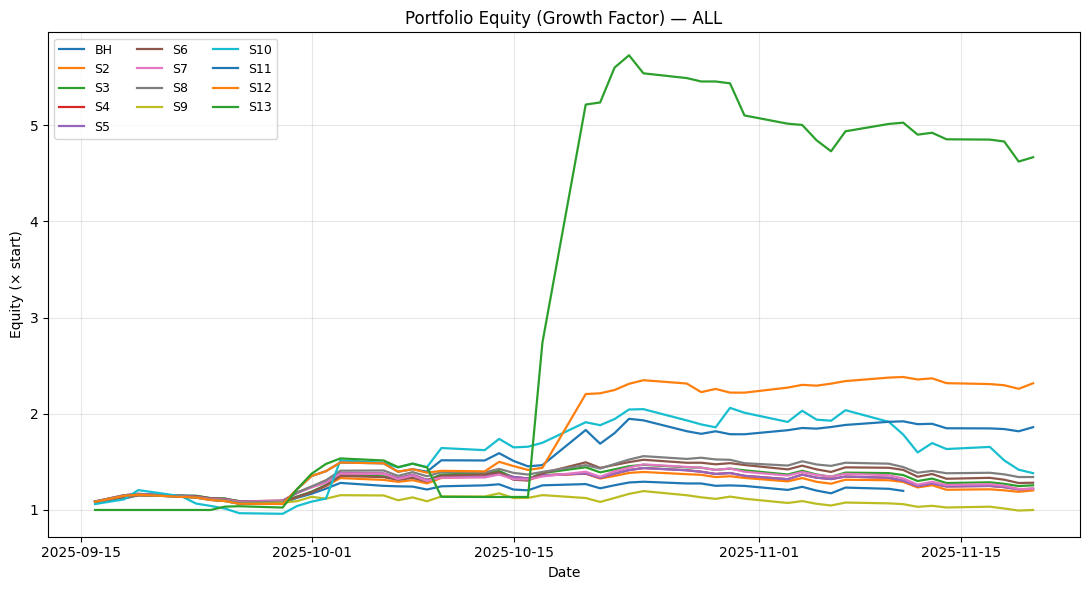

[all] saved out\figs\equity_curves_all.png
[all] wrote out\strat_metrics_all.csv


,strategy,cagr_pct,maxdd_pct,final_equity
0,BH,225.87,-9.30,1.1986
1,S10,517.95,-32.93,1.3828
2,S11,3178.68,-8.59,1.8609
3,S12,11150.33,-8.26,2.3175
4,S13,575362.67,-26.11,4.6680
5,S2,183.05,-14.79,1.2034
6,S3,260.97,-15.05,1.2566
7,S4,206.74,-15.42,1.2207
8,S5,206.74,-15.42,1.2207
9,S6,306.61,-15.87,1.2835


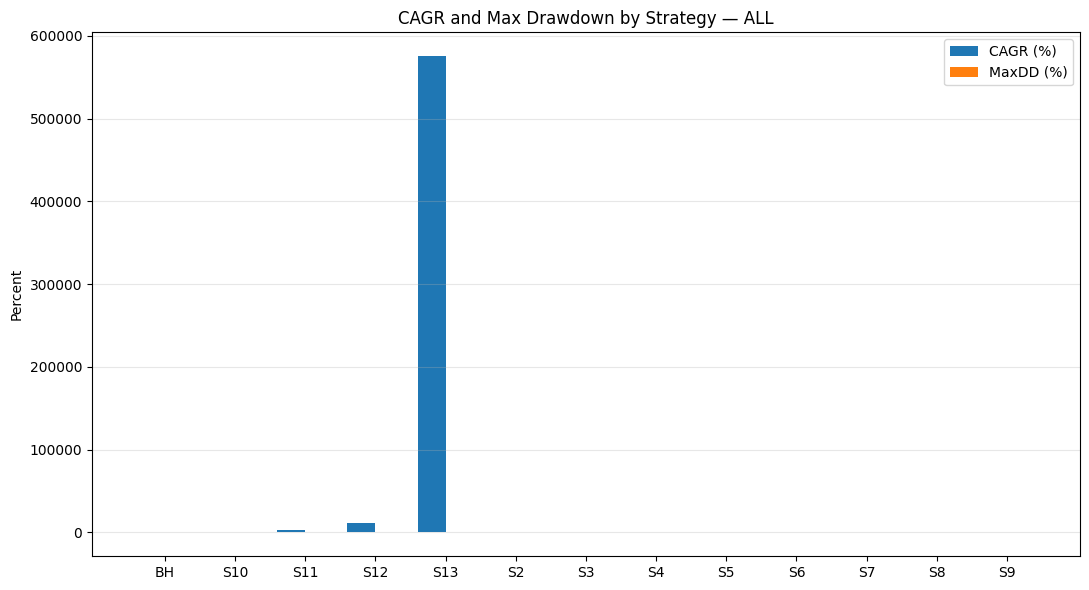

[all] saved out\figs\cagr_maxdd_all.png


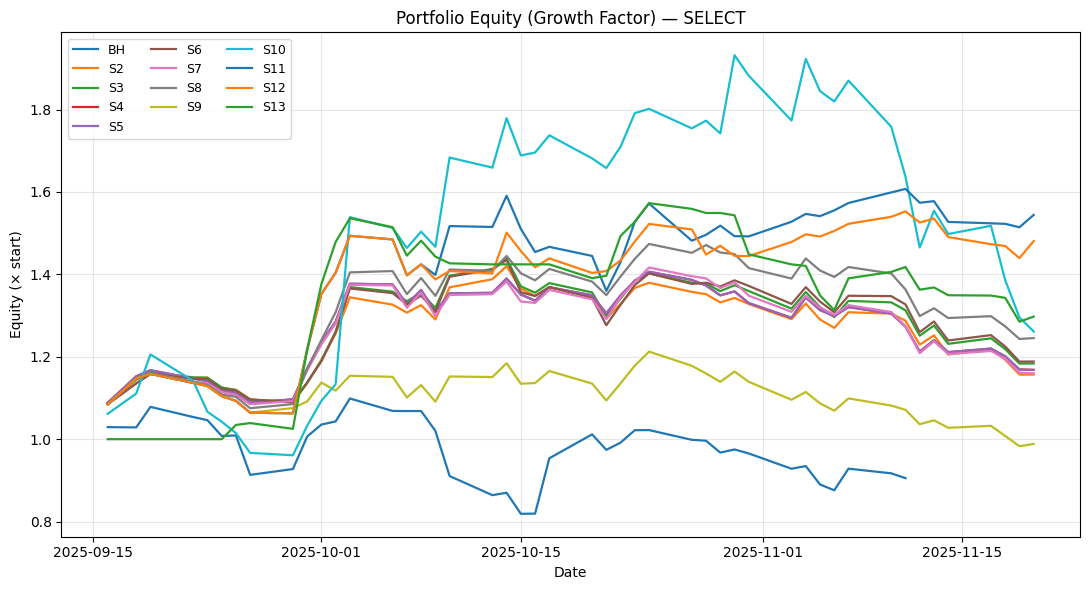

[select] saved out\figs\equity_curves_select.png
[select] wrote out\strat_metrics_select.csv


,strategy,cagr_pct,maxdd_pct,final_equity
0,BH,-47.70,-25.47,0.9054
1,S10,268.90,-34.70,1.2615
2,S11,1049.91,-14.51,1.5444
3,S12,807.80,-8.26,1.4808
4,S13,332.21,-18.30,1.2976
5,S2,126.68,-18.53,1.1568
6,S3,158.11,-17.70,1.1838
7,S4,139.58,-16.93,1.1682
8,S5,139.58,-16.93,1.1682
9,S6,163.91,-17.19,1.1885


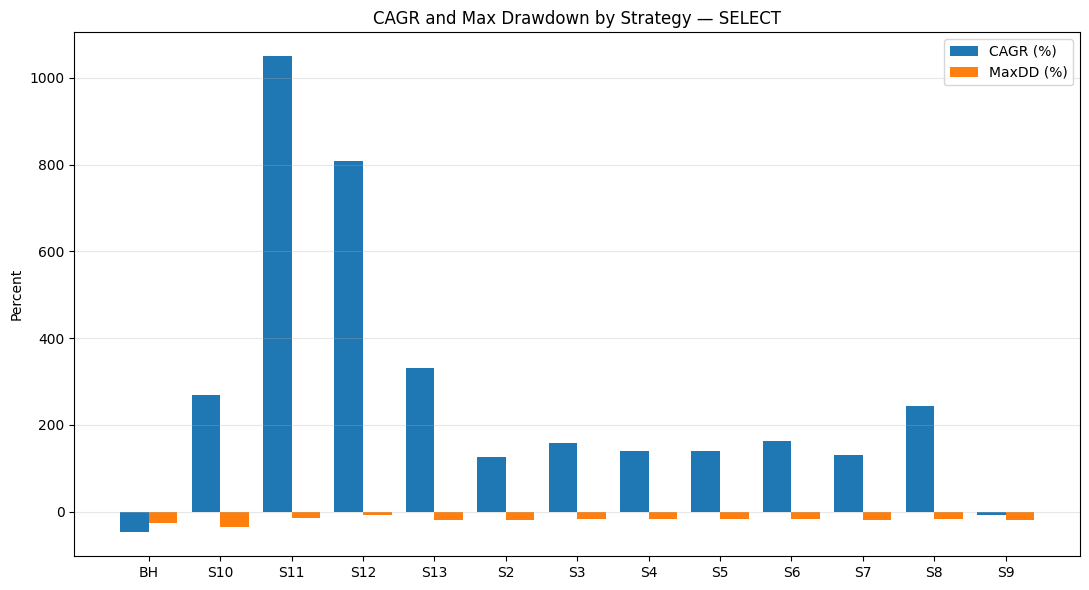

[select] saved out\figs\cagr_maxdd_select.png


In [315]:
# --- Cell H: Equity curves + CAGR/MaxDD charts for ALL and SELECT ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("./out")
FIGS = OUT / "figs"; FIGS.mkdir(parents=True, exist_ok=True)

STRATS = ["BH","S2","S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S13"]

def _load_portfolios(tag: str) -> dict[str, pd.DataFrame]:
    """Load per-strategy daily portfolio CSVs (if present)."""
    dct = {}
    for s in STRATS:
        p = OUT / f"strat_daily_portfolio_{s}_{tag}.csv"
        if p.exists():
            df = pd.read_csv(p, parse_dates=["date"])
            # be forgiving on column names
            if "equity_curve" not in df.columns and "equity" in df.columns and "twr_ret" in df.columns:
                # reconstruct if needed
                df["equity_curve"] = (1.0 + df["twr_ret"].fillna(0.0)).cumprod()
            dct[s] = df.sort_values("date").reset_index(drop=True)
    return dct

def _merge_equity_curves(pdict: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Return wide frame: date + one column per strategy (equity_curve)."""
    curves = None
    for s, df in pdict.items():
        col = df[["date","equity_curve"]].rename(columns={"equity_curve": s})
        curves = col if curves is None else curves.merge(col, on="date", how="outer")
    if curves is None:
        return pd.DataFrame()
    curves = curves.sort_values("date").reset_index(drop=True)
    return curves

def _cagr(equity_curve: pd.Series, dates: pd.Series) -> float:
    if equity_curve.empty:
        return np.nan
    start = dates.iloc[0]
    end   = dates.iloc[-1]
    years = max((end - start).days, 1) / 365.25
    final = float(equity_curve.iloc[-1])
    # equity_curve is a growth factor series (starts near 1.0), CAGR from 1 → final
    return (final ** (1.0 / years)) - 1.0

def _maxdd(equity_curve: pd.Series) -> float:
    if equity_curve.empty:
        return np.nan
    runmax = equity_curve.cummax()
    dd = equity_curve / runmax - 1.0
    return float(dd.min())

def _metrics_table(pdict: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for s, df in pdict.items():
        eq = df["equity_curve"].astype(float)
        dt = df["date"]
        rows.append({
            "strategy": s,
            "cagr": _cagr(eq, dt),
            "maxdd": _maxdd(eq),
            "final_equity": float(eq.iloc[-1]) if not eq.empty else np.nan
        })
    met = pd.DataFrame(rows).sort_values("strategy").reset_index(drop=True)
    return met

def _plot_equity_curves(curves: pd.DataFrame, tag: str):
    if curves.empty:
        print(f"[{tag}] No curves to plot.")
        return
    plt.figure(figsize=(11, 6))
    for s in [c for c in curves.columns if c != "date"]:
        plt.plot(curves["date"], curves[s], label=s, linewidth=1.6)
    plt.title(f"Portfolio Equity (Growth Factor) — {tag.upper()}")
    plt.xlabel("Date"); plt.ylabel("Equity (× start)")
    plt.grid(True, alpha=0.3); plt.legend(ncol=3, fontsize=9)
    out_png = FIGS / f"equity_curves_{tag}.png"
    plt.tight_layout(); plt.savefig(out_png, dpi=140); plt.show()
    print(f"[{tag}] saved {out_png}")

def _plot_cagr_maxdd(met: pd.DataFrame, tag: str):
    if met.empty:
        print(f"[{tag}] No metrics to plot.")
        return
    # single axes with side-by-side bars for CAGR and MaxDD (both in %)
    idx = np.arange(len(met))
    width = 0.4
    plt.figure(figsize=(11, 6))
    plt.bar(idx - width/2, 100.0 * met["cagr"], width, label="CAGR (%)")
    plt.bar(idx + width/2, 100.0 * met["maxdd"], width, label="MaxDD (%)")
    plt.xticks(idx, met["strategy"])
    plt.title(f"CAGR and Max Drawdown by Strategy — {tag.upper()}")
    plt.ylabel("Percent")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    out_png = FIGS / f"cagr_maxdd_{tag}.png"
    plt.tight_layout(); plt.savefig(out_png, dpi=140); plt.show()
    print(f"[{tag}] saved {out_png}")

def run_charts(tag: str):
    pdict = _load_portfolios(tag)
    if not pdict:
        print(f"[{tag}] No strategy files found.")
        return
    curves = _merge_equity_curves(pdict)
    _plot_equity_curves(curves, tag)

    met = _metrics_table(pdict)
    out_csv = OUT / f"strat_metrics_{tag}.csv"
    met.to_csv(out_csv, index=False)
    print(f"[{tag}] wrote {out_csv}")
    display(met.assign(
        cagr_pct=(100*met["cagr"]).round(2),
        maxdd_pct=(100*met["maxdd"]).round(2),
        final_equity=met["final_equity"].round(4)
    )[["strategy","cagr_pct","maxdd_pct","final_equity"]])

    _plot_cagr_maxdd(met, tag)

# ----- Run for ALL and (if present) SELECT -----
run_charts("all")

# Only if you produced SELECT outputs earlier
if any((OUT / f"strat_daily_portfolio_{s}_select.csv").exists() for s in STRATS):
    run_charts("select")
else:
    print("[select] No SELECT strategy files found; skipped.")


In [316]:
# --- Cell: daily per-symbol % from base + append TODAY infer plan ---
from pathlib import Path
import numpy as np
import pandas as pd
import re

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

STRATS = ["BH","S2","S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S13"]
POOLED = {"S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S13"}

SEQUESTERED = {"S2"}

PCT_COLS_FULL = [
    "pct_BH","pct_S2",
    "pct_S3","pct_S4","pct_S5","pct_S6","pct_S7","pct_S8","pct_S9","pct_S10","pct_S11","pct_S12","pct_S13"
]
ACC_MIN_SAMPLES = 20
EPS = 1e-9

# ------------------- helpers: load select universe (optional) -------------------
def _load_select_symbols() -> set:
    if "SELECT_SYMBOLS" in globals():
        try:
            return {str(s).strip().upper() for s in SELECT_SYMBOLS if str(s).strip()}
        except Exception:
            pass
    f = Path("./universe/select_symbols.txt")
    if f.exists():
        toks = re.split(r"[,\s]+", f.read_text(encoding="utf-8").strip())
        return {t.strip().upper() for t in toks if t.strip()}
    return set()

def _score_to_weight(score: pd.Series) -> pd.Series:
    s = pd.to_numeric(score, errors="coerce")
    w = 1.0 + 0.5 * np.clip((s - 0.5) / 0.4, -1, 1)  # rough map to 0.5x..1.5x
    return w.fillna(1.0)

# ------------------- HISTORICAL % from base + per-symbol strategy files -------------------
def _load_per_symbol(strategy: str, tag: str) -> pd.DataFrame | None:
    p = OUT / f"strat_daily_per_symbol_{strategy}_{tag}.csv"
    if not p.exists():
        return None
    d = pd.read_csv(p, parse_dates=["date"])
    d["symbol"] = d["symbol"].astype(str)
    return d

def _history_pcts_for_tag(tag: str, base_slice: pd.DataFrame) -> pd.DataFrame:
    """
    Build one table with daily per-symbol % for all strategies (BH,S2..S10)
    based on historical runs (no today).
    """
    b = base_slice.copy()
    b["date"] = pd.to_datetime(b["date"])
    b["symbol"] = b["symbol"].astype(str)
    b = b.sort_values(["symbol","date"])

    # master key from base
    key = b[["date","symbol"]].drop_duplicates().sort_values(["date","symbol"]).reset_index(drop=True)

    # --- BH from base (equal-weight drift with bh_ret) ---
    df_bh = b.copy()
    df_bh["bh_val"] = (
        df_bh.groupby("symbol")["bh_ret"]
             .apply(lambda s: (1.0 + s.fillna(0.0)).cumprod())
             .reset_index(level=0, drop=True)
    )
    denom = df_bh.groupby("date", as_index=False)["bh_val"].sum().rename(columns={"bh_val":"bh_total"})
    df_bh = df_bh.merge(denom, on="date", how="left")
    df_bh["pct_BH"] = np.where(df_bh["bh_total"] > 0, df_bh["bh_val"] / df_bh["bh_total"], 0.0)
    hist = key.merge(df_bh[["date","symbol","pct_BH"]], on=["date","symbol"], how="left")

    # --- S2..S9 from per-symbol strategy outputs ---
    for strat in STRATS:
        if strat == "BH":
            continue
        d = _load_per_symbol(strat, tag)
        col = f"pct_{strat}"
        if d is None or d.empty:
            hist[col] = 0.0
            continue

        if strat in POOLED:
            eq = pd.to_numeric(d["invested_after"], errors="coerce").fillna(0.0)
        elif strat in SEQUESTERED:
            eq = (
                pd.to_numeric(d["invested_after"], errors="coerce").fillna(0.0)
                + pd.to_numeric(d["cash_after"], errors="coerce").fillna(0.0)
            )
        else:
            hist[col] = 0.0
            continue

        d2 = d.assign(equity_sym=eq)
        denom2 = d2.groupby("date", as_index=False)["equity_sym"].sum().rename(columns={"equity_sym":"equity_total"})
        d2 = d2.merge(denom2, on="date", how="left")
        d2[col] = np.where(d2["equity_total"] > 0, d2["equity_sym"] / d2["equity_total"], 0.0)
        d2 = d2[["date","symbol",col]]
        d2["date"] = pd.to_datetime(d2["date"])
        d2["symbol"] = d2["symbol"].astype(str)

        hist = hist.merge(d2, on=["date","symbol"], how="left")

    # ensure all pct columns exist & numeric
    for c in PCT_COLS_FULL:
        if c not in hist.columns:
            hist[c] = 0.0
        hist[c] = pd.to_numeric(hist[c], errors="coerce").fillna(0.0)

    hist["note"] = "history"
    hist = hist.sort_values(["date","symbol"]).reset_index(drop=True)
    return hist[["date","symbol"] + PCT_COLS_FULL + ["note"]]

# ------------------- TODAY plan from today_inf + base -------------------
def _eligibility_from_base(base_slice: pd.DataFrame) -> pd.DataFrame:
    """
    Compute prior realized TWR metrics for S8/S9 gating, counts for S6/S7 ramp,
    and S11 activation state + active age, using only info up to the last
    row in `base_slice`.
    """
    if base_slice.empty:
        return pd.DataFrame(
            columns=[
                "symbol",
                "twr_cum_prior","twr_roll10_prior",
                "elig_s8","elig_s9",
                "n_seen_prior",
                "elig_s11","active_age_s11",
            ]
        )

    ev = base_slice.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    ev["symbol"] = ev["symbol"].astype(str)
    ev = ev.sort_values(["symbol", "date"])
    grp = ev.groupby("symbol", sort=False)

    # --- cumulative realized TWR up to each row, then shifted to be PRIOR (S8) ---
    cum_twr = grp["realized_ret"].transform(
        lambda s: (1.0 + s.fillna(0.0)).cumprod()
    )
    ev["twr_cum_prior"] = cum_twr.shift(1) - 1.0

    # --- rolling-10 realized TWR up to each row, then shifted to be PRIOR (S9) ---
    def _twr_roll10(s: pd.Series) -> pd.Series:
        vals = (1.0 + s.fillna(0.0)).rolling(window=10, min_periods=10).apply(
            lambda x: float(np.prod(x) - 1.0), raw=True
        )
        return vals

    roll10 = grp["realized_ret"].transform(_twr_roll10)
    ev["twr_roll10_prior"] = roll10.shift(1)

    # latest prior info per symbol
    prior = (
        ev.sort_values(["symbol", "date"])
          .groupby("symbol", as_index=False)
          .tail(1)[["symbol", "twr_cum_prior", "twr_roll10_prior"]]
    )

    prior["elig_s8"] = (prior["twr_cum_prior"] >= -EPS)
    prior["elig_s9"] = (prior["twr_roll10_prior"] > EPS)

    # count of seen rows per symbol (for S6/S7 ramp)
    cnt = base_slice.groupby("symbol", as_index=False).size().rename(columns={"size": "n_seen_prior"})
    prior = prior.merge(cnt, on="symbol", how="outer").fillna({"n_seen_prior": 0})

    # --- S11: final activation + active age as of end of base_slice ---
    if "correct" in ev.columns:
        ev["side"] = ev["side"].astype(str).str.upper()
        ev["is_buy"] = ev["side"].eq("BUY")
        ev["is_sell"] = ev["side"].eq("SELL")
        ev["is_hold"] = ev["side"].eq("HOLD")

        records = []
        for sym, df_sym in ev.groupby("symbol", sort=False):
            active = False
            good_streak = 0
            bad_streak = 0
            age = 0.0

            for _, row in df_sym.iterrows():
                is_signal = bool(row["is_buy"]) or bool(row["is_sell"])
                if not is_signal:
                    if active:
                        age += 1.0
                    continue

                is_corr = bool(row["correct"])
                if is_corr:
                    good_streak += 1
                    bad_streak = 0
                    if (not active) and good_streak >= S11_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                else:
                    bad_streak += 1
                    good_streak = 0
                    if active and bad_streak >= S11_DEACTIVATION_BAD:
                        active = False
                        age = 0.0

                if active:
                    age += 1.0

            records.append({"symbol": sym, "elig_s11": active, "active_age_s11": age})

        s11_df = pd.DataFrame.from_records(records)
        prior = prior.merge(s11_df, on="symbol", how="left")
    else:
        prior["elig_s11"] = False
        prior["active_age_s11"] = 0.0

    prior["elig_s11"] = prior["elig_s11"].fillna(False)
    prior["active_age_s11"] = prior["active_age_s11"].fillna(0.0)
    prior["symbol"] = prior["symbol"].astype(str)
    return prior

def _normalize_today(today_df: pd.DataFrame) -> pd.DataFrame:
    ev = today_df.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    ev["symbol"] = ev["symbol"].astype(str)
    ev["side"] = ev["side"].astype(str).str.upper()
    if "pos_frac" not in ev.columns:
        ev["pos_frac"] = 1.0
    if "score" not in ev.columns:
        ev["score"] = np.nan
    ev["dyn_weight_base"] = _score_to_weight(ev["score"])
    ev["is_buy"]  = ev["side"].eq("BUY")
    ev["is_hold"] = ev["side"].eq("HOLD")
    ev["is_sell"] = ev["side"].eq("SELL")
    return ev.sort_values(["symbol"]).reset_index(drop=True)

def _weights_for_strategy_today(ev0: pd.DataFrame, strat: str) -> pd.DataFrame:
    """
    Return DF [symbol, pct_<strat>] where weights sum to 1 if any symbols present.
    Uses today_inf info + prior info from base for S6/S7/S8/S9 and OOS RL metrics for S10,
    plus S11 activation/age for S11.
    """
    df = ev0.copy()
    df["symbol"] = df["symbol"].astype(str)

    if strat == "S10":
        s10_w = load_s10_train_weights()
        if not s10_w:
            return pd.DataFrame(columns=["symbol", f"pct_{strat}"])
        df = df[df["symbol"].str.upper().isin(s10_w.keys())].copy()
        if df.empty:
            return pd.DataFrame(columns=["symbol", f"pct_{strat}"])
        w = df["pos_frac"].clip(lower=0.0).astype(float)
        c = df["symbol"].str.upper().map(s10_w).astype(float)
        w = w * c

    elif strat == "S11":
        # Only ACTIVE models participate in S11, with seniority boost.
        df = df[df["elig_s11"].fillna(False)].copy()
        if df.empty:
            return pd.DataFrame(columns=["symbol", f"pct_{strat}"])
        w = df["pos_frac"].clip(lower=0.0).astype(float)
        age = df.get("active_age_s11")
        if age is None:
            age = 0.0
        else:
            age = age.fillna(0.0).astype(float)
        age = np.clip(age, 0.0, S11_AGE_CAP)
        mult = 1.0 + age / S11_AGE_DIV
        w = w * mult

    else:
        w = df["pos_frac"].clip(lower=0.0).astype(float)

        if strat in {"S5","S6","S7","S8","S9"}:
            w = w * df["dyn_weight_base"].astype(float)

        if strat in {"S6","S7"}:
            ramp = np.minimum(
                1.0,
                df["n_seen_prior"].fillna(0).astype(float) / float(ACC_MIN_SAMPLES)
            )
            w = w * ramp

        if strat == "S8":
            w = w * df["elig_s8"].fillna(False).astype(float)
        elif strat == "S9":
            w = w * df["elig_s9"].fillna(False).astype(float)

    # Prefer BUYs, otherwise HOLDs, otherwise equal-weight
    w = np.where(df["is_buy"], w, 0.0)
    total = float(np.nansum(w))
    if total > 0:
        w = w / total
    else:
        if df["is_hold"].any():
            mask = df["is_hold"].values
            w = np.zeros(len(df), dtype=float)
            if mask.sum() > 0:
                w[mask] = 1.0 / mask.sum()
        elif len(df) > 0:
            w = np.full(len(df), 1.0 / len(df), dtype=float)
        else:
            return pd.DataFrame(columns=["symbol", f"pct_{strat}"])

    wdf = pd.DataFrame({"symbol": df["symbol"].values, f"pct_{strat}": w})
    wdf = wdf.groupby("symbol", as_index=False).sum()
    wdf["symbol"] = wdf["symbol"].astype(str)
    return wdf


def _today_pcts_for_tag(tag: str, base_slice: pd.DataFrame, today_slice: pd.DataFrame) -> pd.DataFrame:
    """
    Build today's per-symbol % for each strategy:
      - BH/S2: 0 (we don't re-allocate them off today's infer)
      - S3..S9: BUY-weighted with score/evidence/gates
    """
    if today_slice.empty:
        return pd.DataFrame(columns=["date","symbol"] + PCT_COLS_FULL + ["note"])

    prior = _eligibility_from_base(base_slice)
    ev0 = _normalize_today(today_slice).merge(prior, on="symbol", how="left")
    ev0["n_seen_prior"] = ev0["n_seen_prior"].fillna(0)

    out = ev0[["date","symbol"]].drop_duplicates().reset_index(drop=True)

    # S3..S9 pooled strategies
    for strat in sorted(list(POOLED)):
        wdf = _weights_for_strategy_today(ev0, strat)
        col = f"pct_{strat}"
        out = out.merge(wdf, on="symbol", how="left")
        if col not in out.columns:
            out[col] = 0.0
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0.0)

    # BH & S2 are not sized from today's infer → 0
    out["pct_BH"] = 0.0
    out["pct_S2"] = 0.0

    # ensure all pct cols present & in order
    for c in PCT_COLS_FULL:
        if c not in out.columns:
            out[c] = 0.0
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0).clip(0.0, 1.0)

    out["note"] = "today_plan"
    out["date"] = pd.to_datetime(out["date"])
    out["symbol"] = out["symbol"].astype(str)

    # small sanity check: per-strategy sums ≈ 1
    sums = {c: float(out[c].sum()) for c in PCT_COLS_FULL if c not in {"pct_BH","pct_S2"}}
    print(f"[{tag}] today strategy sums:", {k: round(v, 6) for k, v in sums.items()})
    return out[["date","symbol"] + PCT_COLS_FULL + ["note"]].sort_values(["date","symbol"]).reset_index(drop=True)

# ------------------- build ALL + SELECT tables -------------------
assert "base" in globals() and "today_inf" in globals(), "Run the revised Cell D first."

# ALL
hist_all = _history_pcts_for_tag("all", base)
today_all = _today_pcts_for_tag("all", base, today_inf)
alloc_all = pd.concat([hist_all, today_all], ignore_index=True, sort=False)
alloc_all = alloc_all.sort_values(["date","symbol"]).reset_index(drop=True)

path_all = OUT / "alloc_percent_all_with_today.csv"
alloc_all.to_csv(path_all, index=False)
print(f"[ALL] wrote {path_all}  ({len(alloc_all):,} rows)")
display(alloc_all.tail(15))

# SELECT (if configured)
select_set = _load_select_symbols()
if select_set:
    base_sel = base[base["symbol"].isin(select_set)].copy()
    today_sel = today_inf[today_inf["symbol"].isin(select_set)].copy()
    hist_sel = _history_pcts_for_tag("select", base_sel)
    today_sel_tbl = _today_pcts_for_tag("select", base_sel, today_sel)
    alloc_sel = pd.concat([hist_sel, today_sel_tbl], ignore_index=True, sort=False)
    alloc_sel = alloc_sel.sort_values(["date","symbol"]).reset_index(drop=True)
    path_sel = OUT / "alloc_percent_select_with_today.csv"
    alloc_sel.to_csv(path_sel, index=False)
    print(f"[SELECT] wrote {path_sel}  ({len(alloc_sel):,} rows)")
    display(alloc_sel.tail(15))
else:
    print("[SELECT] No SELECT_SYMBOLS configured; only wrote ALL.")


[all] today strategy sums: {'pct_S3': 1.0, 'pct_S4': 1.0, 'pct_S5': 1.0, 'pct_S6': 1.0, 'pct_S7': 1.0, 'pct_S8': 1.0, 'pct_S9': 1.0, 'pct_S10': 1.0, 'pct_S11': 1.0, 'pct_S12': 1.0, 'pct_S13': 1.0}
[ALL] wrote out\alloc_percent_all_with_today.csv  (2,581 rows)


,date,symbol,pct_BH,pct_S2,pct_S3,pct_S4,pct_S5,pct_S6,pct_S7,pct_S8,pct_S9,pct_S10,pct_S11,pct_S12,pct_S13,note
2566,2025-11-21,TRI,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,today_plan
2567,2025-11-21,TRV,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,today_plan
2568,2025-11-21,TSM,0.0,0.0,0.018957,0.018957,0.018957,0.032733,0.032733,0.042105,0.0,0.000000,0.0,0.018957,0.018957,today_plan
2569,2025-11-21,TTD,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,today_plan
2570,2025-11-21,TTWO,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,today_plan
2571,2025-11-21,TXN,0.0,0.0,0.014218,0.014218,0.014218,0.004910,0.004910,0.000000,0.0,0.000000,0.0,0.014218,0.014218,today_plan
2572,2025-11-21,VICR,0.0,0.0,0.018957,0.018957,0.018957,0.032733,0.032733,0.042105,0.0,0.000000,0.0,0.018957,0.018957,today_plan
2573,2025-11-21,VRSK,0.0,0.0,0.018957,0.018957,0.018957,0.006547,0.006547,0.042105,0.0,0.000000,0.0,0.018957,0.018957,today_plan
2574,2025-11-21,VRTX,0.0,0.0,0.009479,0.009479,0.009479,0.003273,0.003273,0.000000,0.0,0.000000,0.0,0.009479,0.009479,today_plan
2575,2025-11-21,VZ,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,today_plan


[select] today strategy sums: {'pct_S3': 1.0, 'pct_S4': 1.0, 'pct_S5': 1.0, 'pct_S6': 1.0, 'pct_S7': 1.0, 'pct_S8': 1.0, 'pct_S9': 1.0, 'pct_S10': 1.0, 'pct_S11': 1.0, 'pct_S12': 1.0, 'pct_S13': 1.0}
[SELECT] wrote out\alloc_percent_select_with_today.csv  (1,998 rows)


,date,symbol,pct_BH,pct_S2,pct_S3,pct_S4,pct_S5,pct_S6,pct_S7,pct_S8,pct_S9,pct_S10,pct_S11,pct_S12,pct_S13,note
1983,2025-11-21,RGTI,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.00,0.00,today_plan
1984,2025-11-21,RMBS,0.0,0.0,0.04,0.04,0.04,0.04,0.04,0.000000,0.000000,0.000000,0.000000,0.04,0.04,today_plan
1985,2025-11-21,RNW,0.0,0.0,0.04,0.04,0.04,0.04,0.04,0.000000,0.133333,0.000000,0.000000,0.04,0.04,today_plan
1986,2025-11-21,ROP,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.00,0.00,today_plan
1987,2025-11-21,SEDG,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.00,0.00,today_plan
1988,2025-11-21,SLDP,0.0,0.0,0.04,0.04,0.04,0.04,0.04,0.076923,0.000000,0.897808,0.000000,0.04,0.04,today_plan
1989,2025-11-21,SMCI,0.0,0.0,0.04,0.04,0.04,0.04,0.04,0.000000,0.000000,0.000000,0.000000,0.04,0.04,today_plan
1990,2025-11-21,SNOW,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.00,0.00,today_plan
1991,2025-11-21,TDC,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.00,0.00,today_plan
1992,2025-11-21,TM,0.0,0.0,0.04,0.04,0.04,0.04,0.04,0.000000,0.000000,0.000024,0.183716,0.04,0.04,today_plan


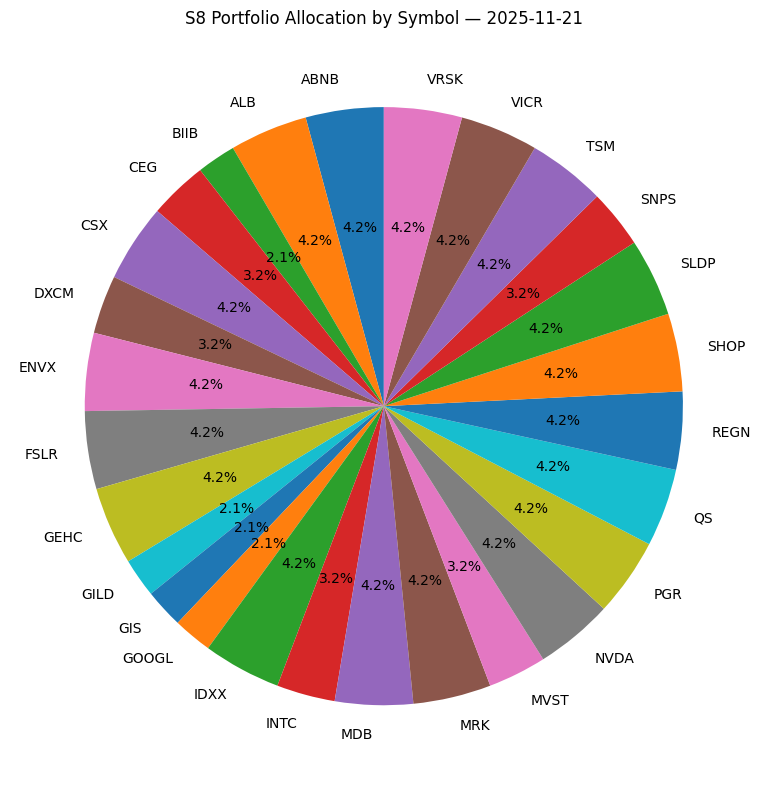

In [317]:
# --- Pie chart: S8 portfolio allocation by symbol for latest date ---

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Load a table that has date, symbol, pct_S8
#    Try in-memory first; fall back to CSV from ./out
df = None

if "alloc_all" in globals() and "pct_S8" in alloc_all.columns:
    df = alloc_all.copy()
elif "alloc_today_all" in globals() and "pct_S8" in alloc_today_all.columns:
    df = alloc_today_all.copy()
else:
    # adjust filename if your alloc file is named differently
    p = Path("./out/alloc_percent_all_with_today.csv")
    if p.exists():
        df = pd.read_csv(p, parse_dates=["date"])
    else:
        p2 = Path("./out/alloc_percent_today_all.csv")
        if p2.exists():
            df = pd.read_csv(p2, parse_dates=["date"])

if df is None or df.empty:
    raise RuntimeError("No allocation file with pct_S8 found.")

# 2. Make sure types are clean
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["symbol"] = df["symbol"].astype(str)
if "pct_S8" not in df.columns:
    raise RuntimeError("DataFrame does not contain a pct_S8 column.")

# 3. Grab the latest date
latest_date = df["date"].max()
today_slice = df[df["date"].eq(latest_date)].copy()

# Prefer symbols with positive S8 weight
today_slice = today_slice[today_slice["pct_S8"] > 0].copy()
# If all zeros, just keep them as equal slices so you can see something
if today_slice.empty:
    today_slice = df[df["date"].eq(latest_date)].copy()

labels = today_slice["symbol"].tolist()
sizes = today_slice["pct_S8"].astype(float).tolist()

# Avoid all-zero pie
if all(v == 0 for v in sizes) and len(sizes) > 0:
    sizes = [1.0 / len(sizes)] * len(sizes)

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title(f"S8 Portfolio Allocation by Symbol — {latest_date.date().isoformat()}")
plt.tight_layout()
plt.show()


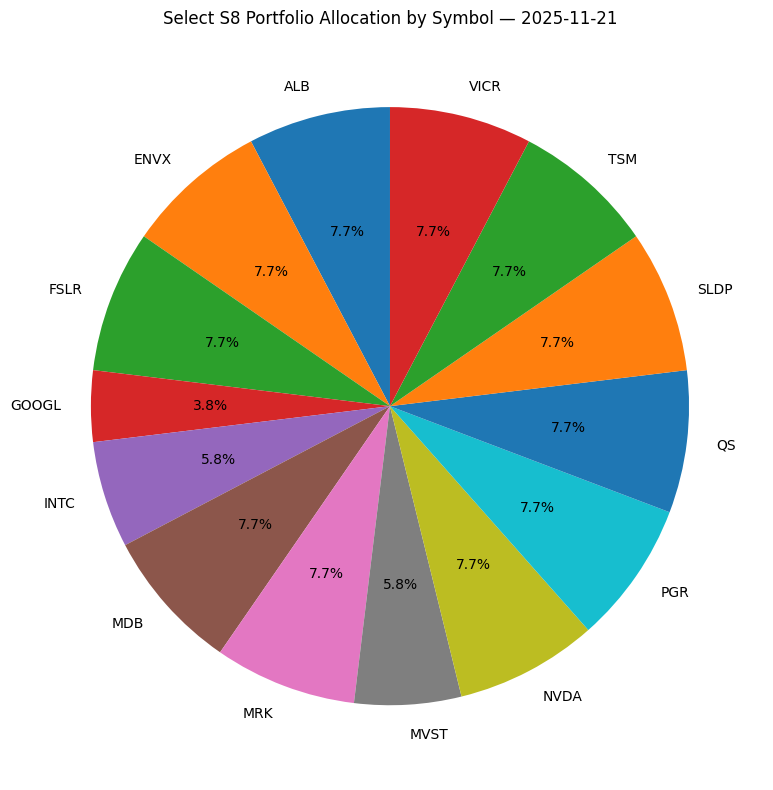

In [318]:
# --- Pie chart: S8 portfolio allocation by symbol for latest date ---

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Load a table that has date, symbol, pct_S8
#    Try in-memory first; fall back to CSV from ./out
df = None

if "alloc_sel" in globals() and "pct_S8" in alloc_sel.columns:
    df = alloc_sel.copy()
elif "alloc_today_sel" in globals() and "pct_S8" in alloc_today_sel.columns:
    df = alloc_today_sel.copy()
else:
    # adjust filename if your alloc file is named differently
    p = Path("./out/alloc_percent_select_with_today.csv")
    if p.exists():
        df = pd.read_csv(p, parse_dates=["date"])
    else:
        p2 = Path("./out/alloc_percent_today_select.csv")
        if p2.exists():
            df = pd.read_csv(p2, parse_dates=["date"])

if df is None or df.empty:
    raise RuntimeError("No allocation file with pct_S8 found.")

# 2. Make sure types are clean
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["symbol"] = df["symbol"].astype(str)
if "pct_S8" not in df.columns:
    raise RuntimeError("DataFrame does not contain a pct_S8 column.")

# 3. Grab the latest date
latest_date = df["date"].max()
today_slice = df[df["date"].eq(latest_date)].copy()

# Prefer symbols with positive S8 weight
today_slice = today_slice[today_slice["pct_S8"] > 0].copy()
# If all zeros, just keep them as equal slices so you can see something
if today_slice.empty:
    today_slice = df[df["date"].eq(latest_date)].copy()

labels = today_slice["symbol"].tolist()
sizes = today_slice["pct_S8"].astype(float).tolist()

# Avoid all-zero pie
if all(v == 0 for v in sizes) and len(sizes) > 0:
    sizes = [1.0 / len(sizes)] * len(sizes)

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title(f"Select S8 Portfolio Allocation by Symbol — {latest_date.date().isoformat()}")
plt.tight_layout()
plt.show()


In [319]:
# --- Cell: Symbol-level infer stats with accuracy & realized_pct ---

import numpy as np
import pandas as pd
from pathlib import Path

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

assert "base" in globals(), "Run Cell D/E first so `base` exists."

b = base.copy()

# Basic hygiene
b = b.dropna(subset=["symbol"]).copy()
b["symbol"] = b["symbol"].astype(str)
b["side"]   = b["side"].astype(str).str.upper()

# Side flags
b["is_buy"]  = b["side"].eq("BUY")
b["is_sell"] = b["side"].eq("SELL")
b["is_hold"] = b["side"].eq("HOLD")

b["n_buy"]  = b["is_buy"].astype(int)
b["n_sell"] = b["is_sell"].astype(int)
b["n_hold"] = b["is_hold"].astype(int)

# Ensure correctness flags exist; if not, rebuild from base logic
for col in ["buy_correct", "sell_correct", "hold_correct", "correct"]:
    if col not in b.columns:
        b[col] = False

b["hit_buy"]  = b["buy_correct"].fillna(False).astype(int)
b["hit_sell"] = b["sell_correct"].fillna(False).astype(int)
b["hit_hold"] = b["hold_correct"].fillna(False).astype(int)
b["hit_overall"] = b["correct"].fillna(False).astype(int)

# Realized_ret for active days only (BUY or HOLD)
b["realized_ret_active"] = np.where(
    b["is_buy"] | b["is_hold"],
    b["realized_ret"].fillna(0.0),
    0.0,
)

# Helper: cumulative pct from daily returns
def _cum_pct(s: pd.Series) -> float:
    return float((1.0 + s.fillna(0.0)).prod() - 1.0)

g = b.groupby("symbol", sort=True)

sym_stats = g.agg(
    n_trades      = ("symbol", "size"),
    n_buy         = ("n_buy", "sum"),
    n_sell        = ("n_sell", "sum"),
    n_hold        = ("n_hold", "sum"),
    buy_hit       = ("hit_buy", "sum"),
    sell_hit      = ("hit_sell", "sum"),
    hold_hit      = ("hit_hold", "sum"),
    overall_hit   = ("hit_overall", "sum"),
    bh_pct        = ("bh_ret", _cum_pct),             # buy & hold over window
    realized_pct  = ("realized_ret_active", _cum_pct) # follow BUY/HOLD signals
)

# Accuracy rates per symbol
sym_stats["buy_acc"]     = np.where(sym_stats["n_buy"]  > 0, sym_stats["buy_hit"]    / sym_stats["n_buy"],  np.nan)
sym_stats["sell_acc"]    = np.where(sym_stats["n_sell"] > 0, sym_stats["sell_hit"]   / sym_stats["n_sell"], np.nan)
sym_stats["hold_acc"]    = np.where(sym_stats["n_hold"] > 0, sym_stats["hold_hit"]   / sym_stats["n_hold"], np.nan)
sym_stats["overall_acc"] = np.where(sym_stats["n_trades"] > 0, sym_stats["overall_hit"] / sym_stats["n_trades"], np.nan)

# Tidy + sort: best realized_pct first, then by n_trades
sym_stats = (
    sym_stats.reset_index()
             .sort_values(["realized_pct", "n_trades"], ascending=[False, False])
)

out_path = OUT / "infer_symbol_stats_all.csv"
sym_stats.to_csv(out_path, index=False)
print(f"Wrote symbol-level infer stats → {out_path.resolve()} ({len(sym_stats):,} symbols)")
display(sym_stats)


Wrote symbol-level infer stats → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\infer_symbol_stats_all.csv (164 symbols)


,symbol,n_trades,n_buy,n_sell,n_hold,buy_hit,sell_hit,hold_hit,overall_hit,bh_pct,realized_pct,buy_acc,sell_acc,hold_acc,overall_acc
27,BYND,47,15,26,6,7,20,1,28,-0.685523,1.737591,0.466667,0.769231,0.166667,0.595745
127,QS,47,30,17,0,17,13,0,30,0.131852,0.962197,0.566667,0.764706,NaN,0.638298
138,SLDP,47,28,19,0,14,9,0,23,0.357240,0.774067,0.500000,0.473684,NaN,0.489362
130,RGTI,47,24,20,3,14,12,0,26,0.176060,0.601204,0.583333,0.600000,0.000000,0.553191
155,VICR,28,11,17,0,7,10,0,17,0.582473,0.205376,0.636364,0.588235,NaN,0.607143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,SMCI,24,15,5,4,6,3,0,9,-0.414743,-0.350575,0.400000,0.600000,0.000000,0.375000
33,CHGG,47,18,20,9,9,10,1,20,-0.354054,-0.369925,0.500000,0.500000,0.111111,0.425532
61,FLNC,24,10,14,0,2,7,0,9,-0.165674,-0.390726,0.200000,0.500000,NaN,0.375000
125,QBTS,47,17,28,2,8,13,0,21,0.073518,-0.399956,0.470588,0.464286,0.000000,0.446809


In [320]:
# --- S11 state table: per symbol, per day, activation + performance counters ---

import numpy as np
import pandas as pd

def build_s11_state_table(base: pd.DataFrame) -> pd.DataFrame:
    """
    For each symbol/date row in `base`, compute S11 activation state and
    performance-related counters.

    Outputs columns:
      symbol, date, side, is_signal, correct,
      active_prior, active_post,
      good_streak, bad_streak, active_age,
      cum_trades, cum_correct, cum_wrong,
      cum_trades_active, cum_correct_active, cum_wrong_active,
      realized_ret (if present in base)
    """
    df = base.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["symbol"] = df["symbol"].astype(str)
    df["side"] = df["side"].astype(str).str.upper()

    df = df.sort_values(["symbol", "date"])

    has_rr = "realized_ret" in df.columns

    rows = []

    for sym, g in df.groupby("symbol", sort=False):
        # S11 state for this symbol
        active = False
        good_streak = 0
        bad_streak = 0
        age = 0.0  # days/rows spent active

        # cumulative performance counts
        cum_trades = 0
        cum_correct = 0
        cum_wrong = 0

        cum_trades_active = 0
        cum_correct_active = 0
        cum_wrong_active = 0

        for _, r in g.iterrows():
            side = r["side"]
            is_buy  = side == "BUY"
            is_sell = side == "SELL"
            is_hold = side == "HOLD"
            is_signal = is_buy or is_sell

            corr = bool(r["correct"]) if "correct" in r.index else False
            rr = float(r["realized_ret"]) if has_rr else np.nan

            # snapshot of state at start of this row (gating state)
            active_prior = active

            # --- update counters and activation based on this row ---

            if is_signal:
                # overall counts
                cum_trades += 1
                if corr:
                    cum_correct += 1
                else:
                    cum_wrong += 1

                # counts while active (state BEFORE update is what matters)
                if active:
                    cum_trades_active += 1
                    if corr:
                        cum_correct_active += 1
                    else:
                        cum_wrong_active += 1

                # streak logic for S11 activation/deactivation
                if corr:
                    good_streak += 1
                    bad_streak = 0
                    if (not active) and good_streak >= S11_ACTIVATION_GOOD:
                        active = True
                        age = 0.0  # reset age on activation
                else:
                    bad_streak += 1
                    good_streak = 0
                    if active and bad_streak >= S11_DEACTIVATION_BAD:
                        active = False
                        age = 0.0  # reset age on deactivation

            # HOLDs do not change streaks; but time still passes if active
            if active:
                age += 1.0

            active_post = active

            rows.append(
                {
                    "symbol": sym,
                    "date": r["date"],
                    "side": side,
                    "is_signal": is_signal,
                    "correct": corr,
                    "active_prior": active_prior,  # state used for gating today
                    "active_post": active_post,    # state after using today's result
                    "good_streak": good_streak,
                    "bad_streak": bad_streak,
                    "active_age": age,
                    "cum_trades": cum_trades,
                    "cum_correct": cum_correct,
                    "cum_wrong": cum_wrong,
                    "cum_trades_active": cum_trades_active,
                    "cum_correct_active": cum_correct_active,
                    "cum_wrong_active": cum_wrong_active,
                    "realized_ret": rr,
                }
            )

    out = pd.DataFrame(rows).sort_values(["symbol", "date"]).reset_index(drop=True)
    return out

# Build and save the S11 state table
s11_state = build_s11_state_table(base)

OUT.mkdir(parents=True, exist_ok=True)
s11_state.to_csv(OUT / "s11_state_daily.csv", index=False)

print("S11 state table saved to", OUT / "s11_state_daily.csv")
display(s11_state.head(50))


S11 state table saved to out\s11_state_daily.csv


,symbol,date,side,is_signal,correct,active_prior,active_post,good_streak,bad_streak,active_age,cum_trades,cum_correct,cum_wrong,cum_trades_active,cum_correct_active,cum_wrong_active,realized_ret
0,AAPL,2025-10-20,SELL,True,False,False,False,0,1,0.0,1,0,1,0,0,0,0.000000
1,AAPL,2025-10-21,SELL,True,True,False,False,1,0,0.0,2,1,1,0,0,0,0.000000
2,AAPL,2025-10-22,SELL,True,False,False,False,0,1,0.0,3,1,2,0,0,0,0.000000
3,AAPL,2025-10-23,BUY,True,True,False,False,1,0,0.0,4,2,2,0,0,0,0.010731
4,AAPL,2025-10-24,SELL,True,False,False,False,0,1,0.0,5,2,3,0,0,0,0.000000
5,AAPL,2025-10-27,SELL,True,False,False,False,0,2,0.0,6,2,4,0,0,0,0.000000
6,AAPL,2025-10-28,SELL,True,True,False,False,1,0,0.0,7,3,4,0,0,0,0.000000
7,AAPL,2025-10-29,BUY,True,True,False,False,2,0,0.0,8,4,4,0,0,0,0.009415
8,AAPL,2025-10-30,SELL,True,True,False,False,3,0,0.0,9,5,4,0,0,0,0.000000
9,AAPL,2025-10-31,SELL,True,True,False,False,4,0,0.0,10,6,4,0,0,0,0.000000


In [321]:
# --- S12 state table: per symbol, per day activation + performance counters ---

import numpy as np
import pandas as pd

def build_s12_state_table(
    base: pd.DataFrame,
    act_good: int | None = None,
    deact_bad: int | None = None,
) -> pd.DataFrame:
    """
    For each symbol/date row in `base`, compute S12 activation state and
    performance-related counters.

    S12 logic:
      - Activate after act_good consecutive correct BUY/SELL signals.
      - While active, deactivate after deact_bad TOTAL wrong BUY/SELL signals
        (they do not need to be consecutive).

    If act_good/deact_bad are None, fall back to S12_ACTIVATION_GOOD /
    S12_DEACTIVATION_BAD globals.
    """
    if act_good is None:
        act_good = S12_ACTIVATION_GOOD
    if deact_bad is None:
        deact_bad = S12_DEACTIVATION_BAD

    df = base.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["symbol"] = df["symbol"].astype(str)
    df["side"] = df["side"].astype(str).str.upper()
    df = df.sort_values(["symbol", "date"])

    has_rr = "realized_ret" in df.columns

    rows = []

    for sym, g in df.groupby("symbol", sort=False):
        # S12 state for this symbol
        active = False
        good_streak = 0              # consecutive correct signals (for activation)
        wrong_since_activation = 0   # total wrong signals while active
        age = 0.0                    # rows/days spent active

        # cumulative performance counts
        cum_trades = cum_correct = cum_wrong = 0
        cum_trades_active = cum_correct_active = cum_wrong_active = 0

        for _, r in g.iterrows():
            side = r["side"]
            is_signal = side in ("BUY", "SELL")
            corr = bool(r["correct"]) if "correct" in r.index else False
            rr = float(r["realized_ret"]) if has_rr else np.nan

            # state at start of this row
            active_prior = active

            if is_signal:
                # overall counts
                cum_trades += 1
                if corr:
                    cum_correct += 1
                else:
                    cum_wrong += 1

                # counts while active (using prior state)
                if active:
                    cum_trades_active += 1
                    if corr:
                        cum_correct_active += 1
                    else:
                        cum_wrong_active += 1

                # --- S12 activation/deactivation ---
                if corr:
                    # consecutive corrects to activate
                    good_streak += 1
                    if (not active) and good_streak >= act_good:
                        active = True
                        age = 0.0
                        wrong_since_activation = 0
                else:
                    # any wrong breaks the good streak
                    good_streak = 0
                    if active:
                        wrong_since_activation += 1
                        if wrong_since_activation >= deact_bad:
                            active = False
                            age = 0.0
                            wrong_since_activation = 0

            # time passes while active (including HOLD rows)
            if active:
                age += 1.0

            active_post = active

            rows.append(
                {
                    "symbol": sym,
                    "date": r["date"],
                    "side": side,
                    "is_signal": is_signal,
                    "correct": corr,
                    "active_prior": active_prior,
                    "active_post": active_post,
                    "good_streak": good_streak,
                    "wrong_since_activation": wrong_since_activation,
                    "active_age": age,
                    "cum_trades": cum_trades,
                    "cum_correct": cum_correct,
                    "cum_wrong": cum_wrong,
                    "cum_trades_active": cum_trades_active,
                    "cum_correct_active": cum_correct_active,
                    "cum_wrong_active": cum_wrong_active,
                    "realized_ret": rr,
                }
            )

    out = pd.DataFrame(rows).sort_values(["symbol", "date"]).reset_index(drop=True)
    return out

# Build + save S12 state
s12_state = build_s12_state_table(base)
OUT.mkdir(parents=True, exist_ok=True)
s12_state.to_csv(OUT / "s12_state_daily.csv", index=False)

print("S12 state table saved to", OUT / "s12_state_daily.csv")
display(s12_state.head(50))


S12 state table saved to out\s12_state_daily.csv


,symbol,date,side,is_signal,correct,active_prior,active_post,good_streak,wrong_since_activation,active_age,cum_trades,cum_correct,cum_wrong,cum_trades_active,cum_correct_active,cum_wrong_active,realized_ret
0,AAPL,2025-10-20,SELL,True,False,False,False,0,0,0.0,1,0,1,0,0,0,0.000000
1,AAPL,2025-10-21,SELL,True,True,False,False,1,0,0.0,2,1,1,0,0,0,0.000000
2,AAPL,2025-10-22,SELL,True,False,False,False,0,0,0.0,3,1,2,0,0,0,0.000000
3,AAPL,2025-10-23,BUY,True,True,False,False,1,0,0.0,4,2,2,0,0,0,0.010731
4,AAPL,2025-10-24,SELL,True,False,False,False,0,0,0.0,5,2,3,0,0,0,0.000000
5,AAPL,2025-10-27,SELL,True,False,False,False,0,0,0.0,6,2,4,0,0,0,0.000000
6,AAPL,2025-10-28,SELL,True,True,False,False,1,0,0.0,7,3,4,0,0,0,0.000000
7,AAPL,2025-10-29,BUY,True,True,False,False,2,0,0.0,8,4,4,0,0,0,0.009415
8,AAPL,2025-10-30,SELL,True,True,False,False,3,0,0.0,9,5,4,0,0,0,0.000000
9,AAPL,2025-10-31,SELL,True,True,False,False,4,0,0.0,10,6,4,0,0,0,0.000000


#parameter tuning for s11
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Helper: run a single S11 variant and compute summary metrics ----------

def run_s11_variant(
    base: pd.DataFrame,
    act_good: int,
    deact_bad: int,
    age_cap: float,
    age_div: float,
    tag: str = "all",
) -> dict:
    """
    Run the S11 strategy with a specific set of parameters and return summary metrics.
    Uses global S11_* parameters and the existing _prep_ev / _eligibility_columns / simulate pipeline.
    """
    global S11_ACTIVATION_GOOD, S11_DEACTIVATION_BAD, S11_AGE_CAP, S11_AGE_DIV

    # 1) Set S11 parameters
    S11_ACTIVATION_GOOD = act_good
    S11_DEACTIVATION_BAD = deact_bad
    S11_AGE_CAP = float(age_cap)
    S11_AGE_DIV = float(age_div)

    # 2) Build event frame, recompute S11 eligibility, and run S11
    ev = _prep_ev(base)                  # add basic flags/pos_frac/score
    ev = _eligibility_columns(ev)        # <-- recompute elig_s8/s9 + S11 activation/age
    port_s11, _ = simulate(ev, strategy="S11")

    port_s11 = port_s11.sort_values("date").reset_index(drop=True)

    equity0 = float(port_s11["equity"].iloc[0])
    equityT = float(port_s11["equity"].iloc[-1])
    n_days = port_s11["date"].nunique()

    daily_ret = port_s11["twr_ret"].fillna(0.0).astype(float)

    # CAGR (assuming 252 trading days/year)
    if n_days > 0 and equity0 > 0:
        cagr = (equityT / equity0) ** (252.0 / n_days) - 1.0
    else:
        cagr = np.nan

    # Max drawdown
    eq = port_s11["equity"].astype(float)
    running_max = eq.cummax()
    dd = eq / running_max - 1.0
    maxdd = float(dd.min()) if len(dd) else np.nan

    # Sharpe (daily, annualized, rf ~ 0)
    if daily_ret.std(ddof=0) > 0:
        sharpe = float(daily_ret.mean() / daily_ret.std(ddof=0) * np.sqrt(252.0))
    else:
        sharpe = np.nan

    return {
        "act_good": act_good,
        "deact_bad": deact_bad,
        "age_cap": age_cap,
        "age_div": age_div,
        "equity_end": equityT,
        "cagr": cagr,
        "maxdd": maxdd,
        "sharpe": sharpe,
        "n_days": int(n_days),
    }

# ---------- S11 parameter sweep ----------

# Choose ranges to explore (start modest; expand later if you like)
ACT_GOOD_LIST   = [3,4,5,10]              # correct-in-a-row to activate
DEACT_BAD_LIST  = [1, 2, 3,4]              # wrong-in-a-row to deactivate
AGE_CAP_LIST    = [10,20.0, 60.0]    # cap on "seniority" days
AGE_DIV_LIST    = [10.0, 20.0, 40.0]     # strength of seniority boost

rows = []

for act_good, deact_bad, age_cap, age_div in product(
    ACT_GOOD_LIST,
    DEACT_BAD_LIST,
    AGE_CAP_LIST,
    AGE_DIV_LIST,
):
    res = run_s11_variant(
        base=base,
        act_good=act_good,
        deact_bad=deact_bad,
        age_cap=age_cap,
        age_div=age_div,
        tag="all",   # or "train"/"oos" if you have tags set up
    )
    rows.append(res)

s11_sweep = pd.DataFrame(rows)

# Optional: Calmar-ish metric (guard against maxdd == 0 or NaN)
s11_sweep["calmar"] = np.where(
    s11_sweep["maxdd"].abs() > 0,
    s11_sweep["cagr"] / s11_sweep["maxdd"].abs(),
    np.nan,
)

# Sort by CAGR (could also sort by 'calmar' or 'sharpe' instead)
s11_sweep = s11_sweep.sort_values("cagr", ascending=False).reset_index(drop=True)

print("Top 10 S11 parameter combos by CAGR:")
display(s11_sweep.head(10))

# Save full sweep for later review
OUT.mkdir(parents=True, exist_ok=True)
s11_sweep.to_csv(OUT / "s11_param_sweep_summary.csv", index=False)

# ---------- Build equity curves for the top 10 combos ----------

# ---------- Build equity curves for the top 10 combos ----------

def s11_equity_curve(
    base: pd.DataFrame,
    act_good: int,
    deact_bad: int,
    age_cap: float,
    age_div: float,
    tag: str = "all",
) -> pd.DataFrame:
    """
    Run S11 for a specific parameter combo and return a normalized equity curve:
    columns: [date, equity, equity_norm, combo]
    """
    global S11_ACTIVATION_GOOD, S11_DEACTIVATION_BAD, S11_AGE_CAP, S11_AGE_DIV

    S11_ACTIVATION_GOOD = act_good
    S11_DEACTIVATION_BAD = deact_bad
    S11_AGE_CAP = float(age_cap)
    S11_AGE_DIV = float(age_div)

    ev = _prep_ev(base)
    ev = _eligibility_columns(ev)        # <-- make sure S11 columns use these params
    port_s11, _ = simulate(ev, strategy="S11")
    port_s11 = port_s11.sort_values("date").reset_index(drop=True)

    df = port_s11[["date", "equity"]].copy()
    df["date"] = pd.to_datetime(df["date"])

    eq0 = df["equity"].iloc[0]
    df["equity_norm"] = df["equity"] / float(eq0) if eq0 > 0 else np.nan

    label = f"g{act_good}-b{deact_bad}-cap{int(age_cap)}-div{int(age_div)}"
    df["combo"] = label
    return df



top10 = s11_sweep.copy()

curves = []
for _, row in top10.iterrows():
    curves.append(
        s11_equity_curve(
            base=base,
            act_good=int(row["act_good"]),
            deact_bad=int(row["deact_bad"]),
            age_cap=float(row["age_cap"]),
            age_div=float(row["age_div"]),
            tag="all",
        )
    )

curves_df = pd.concat(curves, ignore_index=True)

pivot = curves_df.pivot(index="date", columns="combo", values="equity_norm")

# ---------- Plot normalized equity curves for the best 10 combos ----------

plt.figure(figsize=(12, 6))
pivot.plot(ax=plt.gca(), legend=True, alpha=0.8)
plt.ylabel("Normalized equity (start = 1.0)")
plt.xlabel("Date")
plt.title("S11: Normalized equity curves for top 10 parameter combinations (by CAGR)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


#parameter tuning for s12
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Helper: run a single S12 variant and compute summary metrics ----------

def run_s12_variant(
    base: pd.DataFrame,
    act_good: int,
    deact_bad: int,
    age_cap: float,
    age_div: float,
) -> dict:
    """
    Run the S12 strategy with a specific set of parameters and return summary metrics.
    Uses global S12_* parameters and the existing _prep_ev / _eligibility_columns / simulate pipeline.
    """
    global S12_ACTIVATION_GOOD, S12_DEACTIVATION_BAD, S12_AGE_CAP, S12_AGE_DIV

    # 1) Set S12 parameters
    S12_ACTIVATION_GOOD = act_good
    S12_DEACTIVATION_BAD = deact_bad
    S12_AGE_CAP = float(age_cap)
    S12_AGE_DIV = float(age_div)

    # 2) Build event frame, recompute eligibilities (including S12), and run S12
    ev = _prep_ev(base)
    ev = _eligibility_columns(ev)
    port_s12, _ = simulate(ev, strategy="S12")

    port_s12 = port_s12.sort_values("date").reset_index(drop=True)

    equity0 = float(port_s12["equity"].iloc[0])
    equityT = float(port_s12["equity"].iloc[-1])
    n_days = port_s12["date"].nunique()

    daily_ret = port_s12["twr_ret"].fillna(0.0).astype(float)

    # CAGR (assuming 252 trading days/year)
    if n_days > 0 and equity0 > 0:
        cagr = (equityT / equity0) ** (252.0 / n_days) - 1.0
    else:
        cagr = np.nan

    # Max drawdown
    eq = port_s12["equity"].astype(float)
    running_max = eq.cummax()
    dd = eq / running_max - 1.0
    maxdd = float(dd.min()) if len(dd) else np.nan

    # Sharpe (daily, annualized, rf ~ 0)
    if daily_ret.std(ddof=0) > 0:
        sharpe = float(daily_ret.mean() / daily_ret.std(ddof=0) * np.sqrt(252.0))
    else:
        sharpe = np.nan

    return {
        "act_good": act_good,
        "deact_bad": deact_bad,
        "age_cap": age_cap,
        "age_div": age_div,
        "equity_end": equityT,
        "cagr": cagr,
        "maxdd": maxdd,
        "sharpe": sharpe,
        "n_days": int(n_days),
    }

# ---------- S12 parameter sweep ----------

# Start with a modest grid; you can widen/narrow these later
S12_ACT_GOOD_LIST   = [2,3, 4, 5,6]           # consecutive correct to activate
S12_DEACT_BAD_LIST  = [1,2, 3, 4]           # TOTAL wrong while active to deactivate
S12_AGE_CAP_LIST    = [20.0, 60.0]
S12_AGE_DIV_LIST    = [10.0, 20.0, 40.0]

rows = []

for act_good, deact_bad, age_cap, age_div in product(
    S12_ACT_GOOD_LIST,
    S12_DEACT_BAD_LIST,
    S12_AGE_CAP_LIST,
    S12_AGE_DIV_LIST,
):
    res = run_s12_variant(
        base=base,
        act_good=act_good,
        deact_bad=deact_bad,
        age_cap=age_cap,
        age_div=age_div,
    )
    rows.append(res)

s12_sweep = pd.DataFrame(rows)

# Calmar-ish metric
s12_sweep["calmar"] = np.where(
    s12_sweep["maxdd"].abs() > 0,
    s12_sweep["cagr"] / s12_sweep["maxdd"].abs(),
    np.nan,
)

# Sort by CAGR (you can swap to 'calmar' or 'sharpe' if you prefer)
s12_sweep = s12_sweep.sort_values("cagr", ascending=False).reset_index(drop=True)

print("Top 10 S12 parameter combos by CAGR:")
display(s12_sweep.head(10))

OUT.mkdir(parents=True, exist_ok=True)
s12_sweep.to_csv(OUT / "s12_param_sweep_summary.csv", index=False)

# ---------- Build equity curves for the top 10 S12 combos ----------

def s12_equity_curve(
    base: pd.DataFrame,
    act_good: int,
    deact_bad: int,
    age_cap: float,
    age_div: float,
) -> pd.DataFrame:
    """
    Run S12 for a specific parameter combo and return a normalized equity curve:
    columns: [date, equity, equity_norm, combo]
    """
    global S12_ACTIVATION_GOOD, S12_DEACTIVATION_BAD, S12_AGE_CAP, S12_AGE_DIV

    S12_ACTIVATION_GOOD = act_good
    S12_DEACTIVATION_BAD = deact_bad
    S12_AGE_CAP = float(age_cap)
    S12_AGE_DIV = float(age_div)

    ev = _prep_ev(base)
    ev = _eligibility_columns(ev)
    port_s12, _ = simulate(ev, strategy="S12")
    port_s12 = port_s12.sort_values("date").reset_index(drop=True)

    df = port_s12[["date", "equity"]].copy()
    df["date"] = pd.to_datetime(df["date"])

    eq0 = df["equity"].iloc[0]
    df["equity_norm"] = df["equity"] / float(eq0) if eq0 > 0 else np.nan

    label = f"S12_g{act_good}-b{deact_bad}-cap{int(age_cap)}-div{int(age_div)}"
    df["combo"] = label
    return df


top10_s12 = s12_sweep.head(10).copy()

curves = []
for _, row in top10_s12.iterrows():
    curves.append(
        s12_equity_curve(
            base=base,
            act_good=int(row["act_good"]),
            deact_bad=int(row["deact_bad"]),
            age_cap=float(row["age_cap"]),
            age_div=float(row["age_div"]),
        )
    )

curves_df = pd.concat(curves, ignore_index=True)

pivot = curves_df.pivot(index="date", columns="combo", values="equity_norm")

# ---------- Plot normalized equity curves for the best 10 S12 combos ----------

plt.figure(figsize=(12, 6))
pivot.plot(ax=plt.gca(), legend=True, alpha=0.8)
plt.ylabel("Normalized equity (start = 1.0)")
plt.xlabel("Date")
plt.title("S12: Normalized equity curves for top 10 parameter combinations (by CAGR)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


# === S13 parameter tuning ===
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Helper: run a single S13 variant and compute summary metrics ----------

def run_s13_variant(
    base: pd.DataFrame,
    act_good: int,
    deact_bad: int,
    age_cap: float,
    age_div: float,
) -> dict:
    """
    Run the S13 strategy with a specific set of S12 gating parameters
    and return summary metrics.

    Uses global S12_* parameters and the existing
    _prep_ev / _eligibility_columns / simulate pipeline.
    """
    global S12_ACTIVATION_GOOD, S12_DEACTIVATION_BAD, S12_AGE_CAP, S12_AGE_DIV

    # 1) Set S12 parameters that drive S13's gating
    S12_ACTIVATION_GOOD = act_good
    S12_DEACTIVATION_BAD = deact_bad
    S12_AGE_CAP = float(age_cap)
    S12_AGE_DIV = float(age_div)

    # 2) Build event frame, recompute eligibilities (including S12), and run S13
    ev = _prep_ev(base)
    ev = _eligibility_columns(ev)
    port_s13, _ = simulate(ev, strategy="S13")

    port_s13 = port_s13.sort_values("date").reset_index(drop=True)

    equity0 = float(port_s13["equity"].iloc[0])
    equityT = float(port_s13["equity"].iloc[-1])
    n_days = port_s13["date"].nunique()

    daily_ret = port_s13["twr_ret"].fillna(0.0).astype(float)

    # CAGR (assuming 252 trading days/year)
    if n_days > 0 and equity0 > 0:
        cagr = (equityT / equity0) ** (252.0 / n_days) - 1.0
    else:
        cagr = np.nan

    # Max drawdown
    eq = port_s13["equity"].astype(float)
    running_max = eq.cummax()
    dd = eq / running_max - 1.0
    maxdd = float(dd.min()) if len(dd) else np.nan

    # Sharpe (daily, annualized, rf ~ 0)
    if daily_ret.std(ddof=0) > 0:
        sharpe = float(daily_ret.mean() / daily_ret.std(ddof=0) * np.sqrt(252.0))
    else:
        sharpe = np.nan

    return {
        "act_good": act_good,
        "deact_bad": deact_bad,
        "age_cap": age_cap,
        "age_div": age_div,
        "equity_end": equityT,
        "cagr": cagr,
        "maxdd": maxdd,
        "sharpe": sharpe,
        "n_days": int(n_days),
    }

# ---------- S13 parameter sweep ----------

# You can adjust these ranges as needed
S13_ACT_GOOD_LIST   = [2, 3, 4, 5, 6]        # consecutive correct to activate
S13_DEACT_BAD_LIST  = [1, 2, 3, 4]           # TOTAL wrong while active to deactivate
S13_AGE_CAP_LIST    = [20.0, 60.0]           # cap on seniority days
S13_AGE_DIV_LIST    = [10.0, 20.0, 40.0]     # strength of age boost

rows = []

for act_good, deact_bad, age_cap, age_div in product(
    S13_ACT_GOOD_LIST,
    S13_DEACT_BAD_LIST,
    S13_AGE_CAP_LIST,
    S13_AGE_DIV_LIST,
):
    res = run_s13_variant(
        base=base_sel,   # or base_sel if you want SELECT only
        act_good=act_good,
        deact_bad=deact_bad,
        age_cap=age_cap,
        age_div=age_div,
    )
    rows.append(res)

s13_sweep = pd.DataFrame(rows)

# Calmar-ish metric
s13_sweep["calmar"] = np.where(
    s13_sweep["maxdd"].abs() > 0,
    s13_sweep["cagr"] / s13_sweep["maxdd"].abs(),
    np.nan,
)

# Sort by CAGR (swap to 'calmar' or 'sharpe' if you prefer)
s13_sweep = s13_sweep.sort_values("cagr", ascending=False).reset_index(drop=True)

print("Top 10 S13 parameter combos by CAGR:")
display(s13_sweep.head(10))

OUT.mkdir(parents=True, exist_ok=True)
s13_sweep.to_csv(OUT / "s13_param_sweep_summary.csv", index=False)

# ---------- Build equity curves for the top 10 S13 combos ----------

def s13_equity_curve(
    base: pd.DataFrame,
    act_good: int,
    deact_bad: int,
    age_cap: float,
    age_div: float,
) -> pd.DataFrame:
    """
    Run S13 for a specific parameter combo and return a normalized equity curve:
    columns: [date, equity, equity_norm, combo]
    """
    global S12_ACTIVATION_GOOD, S12_DEACTIVATION_BAD, S12_AGE_CAP, S12_AGE_DIV

    S12_ACTIVATION_GOOD = act_good
    S12_DEACTIVATION_BAD = deact_bad
    S12_AGE_CAP = float(age_cap)
    S12_AGE_DIV = float(age_div)

    ev = _prep_ev(base)
    ev = _eligibility_columns(ev)
    port_s13, _ = simulate(ev, strategy="S13")
    port_s13 = port_s13.sort_values("date").reset_index(drop=True)

    df = port_s13[["date", "equity"]].copy()
    df["date"] = pd.to_datetime(df["date"])

    eq0 = df["equity"].iloc[0]
    df["equity_norm"] = df["equity"] / float(eq0) if eq0 > 0 else np.nan

    label = f"S13_g{act_good}-b{deact_bad}-cap{int(age_cap)}-div{int(age_div)}"
    df["combo"] = label
    return df


top10_s13 = s13_sweep.head(10).copy()

curves = []
for _, row in top10_s13.iterrows():
    curves.append(
        s13_equity_curve(
            base=base,
            act_good=int(row["act_good"]),
            deact_bad=int(row["deact_bad"]),
            age_cap=float(row["age_cap"]),
            age_div=float(row["age_div"]),
        )
    )

curves_df = pd.concat(curves, ignore_index=True)

pivot = curves_df.pivot(index="date", columns="combo", values="equity_norm")

# ---------- Plot normalized equity curves for the best 10 S13 combos ----------

plt.figure(figsize=(12, 6))
pivot.plot(ax=plt.gca(), legend=True, alpha=0.8)
plt.ylabel("Normalized equity (start = 1.0)")
plt.xlabel("Date")
plt.title("S13: Normalized equity curves for top 10 parameter combinations (by CAGR)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


In [322]:

# 1) Rebuild ev with eligibility (Cell F logic)
ev = _prep_ev(base)
ev = _eligibility_columns(ev)

# 2) Rebuild S11 state table (tracker logic)
s11_state = build_s11_state_table(base)

chk11 = (
    ev.merge(
        s11_state[["symbol","date","active_prior"]],
        on=["symbol","date"],
        how="inner",
        suffixes=("", "_state")
    )
)

diff11 = (chk11["elig_s11"].astype(bool) != chk11["active_prior"].astype(bool)).sum()
print("S11 rows with mismatched active state:", diff11)

ev = _prep_ev(base)
ev = _eligibility_columns(ev)

s12_state = build_s12_state_table(base)
chk12 = (
    ev.merge(
        s12_state[["symbol","date","active_prior"]],
        on=["symbol","date"],
        how="inner",
        suffixes=("", "_state")
    )
)

diff12 = (chk12["elig_s12"].astype(bool) != chk12["active_prior"].astype(bool)).sum()
print("S12 rows with mismatched active state:", diff12)

S11 rows with mismatched active state: 0
S12 rows with mismatched active state: 0


In [323]:
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("./out")

port_all = pd.read_csv(OUT / "strat_daily_portfolio.csv", parse_dates=["date"])
port_s12 = port_all[port_all["strategy"] == "S12"].sort_values("date").reset_index(drop=True)

# Rebuild equity from twr_ret
eq0 = float(port_s12["equity"].iloc[0])
rebuilt = eq0 * (1.0 + port_s12["twr_ret"].fillna(0.0).astype(float)).cumprod()

diff = (rebuilt - port_s12["equity"]).abs()
print("Max abs difference between reported equity and rebuilt equity:", diff.max())


Max abs difference between reported equity and rebuilt equity: 263542.59366583364


In [324]:
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("./out")

port_all = pd.read_csv(OUT / "strat_daily_portfolio.csv", parse_dates=["date"])
port_s12 = port_all[port_all["strategy"] == "S12"].sort_values("date").reset_index(drop=True)

# Build the equity curve index (this is what the chart uses)
equity_curve = (1.0 + port_s12["twr_ret"].fillna(0.0).astype(float)).cumprod()

port_s12["equity_curve"] = equity_curve

print(port_s12[["date","equity","twr_ret","equity_curve"]].head(10))


        date       equity   twr_ret  equity_curve
0 2025-09-16  4101.223999  0.000000      1.000000
1 2025-09-16  4101.223999  0.000000      1.000000
2 2025-09-18  4335.702973  0.057173      1.057173
3 2025-09-18  4335.702973  0.057173      1.117615
4 2025-09-19  4373.920579  0.008815      1.127466
5 2025-09-19  4373.920579  0.008815      1.137404
6 2025-09-22  4270.646331 -0.023611      1.110548
7 2025-09-22  4270.646331 -0.023611      1.084327
8 2025-09-23  4243.593106 -0.006335      1.077458
9 2025-09-23  4243.593106 -0.006335      1.070633


In [325]:
bh = port_all[port_all["strategy"] == "BH"].sort_values("date").reset_index(drop=True)

comp = port_s12[["date","twr_ret"]].merge(
    bh[["date","twr_ret"]].rename(columns={"twr_ret": "bh_ret"}),
    on="date",
    how="inner"
)

print("S12 daily mean/std:", comp["twr_ret"].mean(), comp["twr_ret"].std())
print(" BH daily mean/std:", comp["bh_ret"].mean(), comp["bh_ret"].std())
print("Share of days S12 > BH:",
      (comp["twr_ret"] > comp["bh_ret"]).mean())


S12 daily mean/std: 0.0400020589186136 0.14949821111343287
 BH daily mean/std: 0.003887399665920866 0.03190203339949393
Share of days S12 > BH: 0.5365853658536586


In [326]:
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("./out")

# --------- 0) Choose universe + day to inspect ---------
TAG = "select"      # or "select" or "all"
TARGET_DATE = pd.Timestamp("2025-11-07")  # change as needed

# --------- 1) Build the matching base slice (ALL vs SELECT) ---------
if TAG == "all":
    base_tag = base.copy()
elif TAG == "select":
    # use the same helper Cell F uses
    select_set = _load_select_symbols()
    if not select_set:
        raise ValueError("TAG='select' but no SELECT symbols defined.")
    base_tag = base[base["symbol"].isin(select_set)].copy()
else:
    raise ValueError("TAG must be 'all' or 'select'.")

# --------- 2) Rebuild events + S12 eligibility for that slice ---------
ev = _prep_ev(base_tag)
ev = _eligibility_columns(ev)

ev_day = ev[ev["date"] == TARGET_DATE].copy()

ev_day["s12_active"] = ev_day["elig_s12"].fillna(False)
ev_day["s12_age"]    = ev_day.get("active_age_s12", 0.0)

active_day = (
    ev_day[ev_day["s12_active"]]
    .loc[:, ["symbol", "side", "pos_frac", "score", "s12_age", "correct", "ret_next"]]
    .sort_values("symbol")
    .reset_index(drop=True)
)

print(f"[{TAG}] S12 ACTIVE MODELS on {TARGET_DATE.date()} (start of day):")
display(active_day)

active_buys = active_day[active_day["side"] == "BUY"].copy()
print(f"\n[{TAG}] S12 ACTIVE + BUY signals on {TARGET_DATE.date()}:")
display(active_buys)

# --------- 3) Load the matching S12 per-symbol ledger (ALL vs SELECT) ---------
sym_path  = OUT / f"strat_daily_per_symbol_S12_{TAG}.csv"
port_path = OUT / f"strat_daily_portfolio_S12_{TAG}.csv"

if not sym_path.exists():
    raise FileNotFoundError(f"Missing {sym_path.name} — did you rerun Cell F with S12 included?")
if not port_path.exists():
    raise FileNotFoundError(f"Missing {port_path.name} — did you rerun Cell F with S12 included?")

sym_s12  = pd.read_csv(sym_path, parse_dates=["date"])
port_s12 = pd.read_csv(port_path, parse_dates=["date"]).sort_values("date")

ledger_day = (
    sym_s12[sym_s12["date"] == TARGET_DATE]
    .loc[:, ["symbol", "alloc_w", "contrib_ret", "invested_after", "cash_after"]]
    .sort_values("alloc_w", ascending=False)
    .reset_index(drop=True)
)

print(f"\n[{TAG}] S12 per-symbol ledger on {TARGET_DATE.date()} (after D->D+1 returns):")
display(ledger_day)

# --------- 4) Join: S12-active BUYs + weight + outcome ---------
view = (
    active_buys.merge(
        ledger_day,
        on="symbol",
        how="left",
    )
    .sort_values("alloc_w", ascending=False)
    .reset_index(drop=True)
)

view["next_day_ret_pct"] = view["ret_next"].astype(float) * 100.0
view["pnl_contrib_pct"]  = view["contrib_ret"].astype(float) * 100.0

print(f"\n[{TAG}] S12 ACTIVE BUYs on {TARGET_DATE.date()} with D->D+1 outcomes:")
display(
    view[
        [
            "symbol",
            "side",
            "pos_frac",
            "score",
            "s12_age",
            "correct",
            "next_day_ret_pct",
            "alloc_w",
            "pnl_contrib_pct",
            "invested_after",
        ]
    ]
)

# --------- 5) Sanity check: contrib_ret vs daily TWR ---------
twr_day = float(port_s12.loc[port_s12["date"] == TARGET_DATE, "twr_ret"].iloc[0])
sum_contrib = float(ledger_day["contrib_ret"].sum())

print(
    f"\n[{TAG}] Sanity check for {TARGET_DATE.date()}:"
    f"\n  S12 twr_ret (portfolio)          = {twr_day:.6f}"
    f"\n  Sum of contrib_ret (per-symbol)  = {sum_contrib:.6f}"
)


[select] S12 ACTIVE MODELS on 2025-11-07 (start of day):


,symbol,side,pos_frac,score,s12_age,correct,ret_next
0,ENPH,HOLD,0.2,NaN,7.0,False,0.089356
1,LCID,SELL,0.2,NaN,9.0,False,0.020361
2,MVST,BUY,0.4,NaN,6.0,True,0.081053
3,POWI,SELL,0.2,NaN,1.0,False,0.032216
4,TM,BUY,0.4,NaN,2.0,True,0.006980



[select] S12 ACTIVE + BUY signals on 2025-11-07:


,symbol,side,pos_frac,score,s12_age,correct,ret_next
2,MVST,BUY,0.4,NaN,6.0,True,0.081053
4,TM,BUY,0.4,NaN,2.0,True,0.006980



[select] S12 per-symbol ledger on 2025-11-07 (after D->D+1 returns):


,symbol,alloc_w,contrib_ret,invested_after,cash_after
0,AEP,0.0,0.0,0.000000,0.0
1,AI,0.0,0.0,0.000000,0.0
2,ALB,0.0,0.0,0.000000,0.0
3,AMD,0.0,0.0,0.000000,0.0
4,AMSC,0.0,0.0,0.000000,0.0
5,ARQQ,0.0,0.0,0.000000,0.0
6,ARRY,0.0,0.0,0.000000,0.0
7,BHP,0.0,0.0,0.000000,0.0
8,CHGG,0.0,-0.0,0.000000,0.0
9,CLNE,0.0,0.0,0.000000,0.0



[select] S12 ACTIVE BUYs on 2025-11-07 with D->D+1 outcomes:


,symbol,side,pos_frac,score,s12_age,correct,next_day_ret_pct,alloc_w,pnl_contrib_pct,invested_after
0,MVST,BUY,0.4,NaN,6.0,True,8.105263,0.0,0.0,0.0
1,TM,BUY,0.4,NaN,2.0,True,0.697985,0.0,0.0,0.0



[select] Sanity check for 2025-11-07:
  S12 twr_ret (portfolio)          = 0.011495
  Sum of contrib_ret (per-symbol)  = 0.000000


In [331]:
from pathlib import Path
import pandas as pd

OUT = Path("./out")

# ---- config: which universe & strategy to inspect ----
TAG   = "select"          # "all" or "select"
STRAT = "S11"             # you can change to "S12" or "S11" later

# ---- 1) Load S13 per-symbol ledger (what the sim wrote) ----
sym_path  = OUT / f"strat_daily_per_symbol_{STRAT}_{TAG}.csv"
port_path = OUT / f"strat_daily_portfolio_{STRAT}_{TAG}.csv"

print("Per-symbol file:", sym_path)
print("Portfolio file: ", port_path)

sym = pd.read_csv(sym_path, parse_dates=["date"])
port = pd.read_csv(port_path, parse_dates=["date"])

# ---- 2) Rebuild the matching event frame (to get side, pos_frac, S12 active flags, etc.) ----
if TAG == "select":
    base_tag = base.copy()
else:
    select_set = _load_select_symbols()
    base_tag = base[base["symbol"].isin(select_set)].copy()

ev = _prep_ev(base_tag)
ev = _eligibility_columns(ev)

# Keep the columns we care about
ev_sub = ev[
    [
        "date",
        "symbol",
        "side",
        "pos_frac",
        "correct",
        "ret_next",
        "elig_s12",
        "active_age_s12",
    ]
].copy()

# ---- 3) Join: S13 per-symbol ledger + event info + daily equity curve ----
ledger = (
    sym.merge(ev_sub, on=["date", "symbol"], how="left")
       .merge(
           port[["date", "twr_ret", "equity", "equity_curve"]],
           on="date",
           how="left",
       )
       .sort_values(["date", "symbol"])
       .reset_index(drop=True)
)

# handy % columns
ledger["ret_next_pct"]   = ledger["ret_next"].astype(float) * 100.0
ledger["contrib_pct"]    = ledger["contrib_ret"].astype(float) * 100.0

print(f"{STRAT} ledger shape:", ledger.shape)

# ---- 4) Example views ----

# a) Whole thing (careful, this can be big)
display(ledger.head(50))

# b) Specific day
DAY = "2025-11-19"
print(f"\n=== {STRAT} per-symbol ledger on {DAY} ({TAG}) ===")
display(ledger[ledger["date"] == DAY])

# c) Date range
start, end = "2025-11-10", "2025-11-21"
print(f"\n=== {STRAT} per-symbol ledger from {start} to {end} ({TAG}) ===")
mask = (ledger["date"] >= start) & (ledger["date"] <= end)
display(ledger.loc[mask])

# d) Save full ledger to CSV for Data Wrangler / Excel
out_debug = OUT / f"debug_{STRAT}_ledger_{TAG}.csv"
ledger.to_csv(out_debug, index=False)
print("Wrote full ledger to:", out_debug)


Per-symbol file: out\strat_daily_per_symbol_S11_select.csv
Portfolio file:  out\strat_daily_portfolio_S11_select.csv
S11 ledger shape: (1941, 18)


,date,symbol,strategy,alloc_w,contrib_ret,invested_after,cash_after,side,pos_frac,correct,ret_next,elig_s12,active_age_s12,twr_ret,equity,equity_curve,ret_next_pct,contrib_pct
0,2025-09-16,AI,S11,0.100000,0.004242,373.509423,0.0,BUY,0.3,True,0.042424,False,0.0,0.084523,3885.938066,1.084523,4.242424,0.424242
1,2025-09-16,AMD,S11,0.100000,-0.001541,352.787801,0.0,BUY,0.3,False,-0.015408,False,0.0,0.084523,3885.938066,1.084523,-1.540755,-0.154076
2,2025-09-16,CHGG,S11,0.000000,0.000000,0.000000,0.0,SELL,0.3,False,0.074324,False,0.0,0.084523,3885.938066,1.084523,7.432432,0.000000
3,2025-09-16,GOOGL,S11,0.000000,-0.000000,0.000000,0.0,SELL,0.3,True,-0.001310,False,0.0,0.084523,3885.938066,1.084523,-0.130958,-0.000000
4,2025-09-16,IBM,S11,0.000000,0.000000,0.000000,0.0,SELL,0.4,False,0.028448,False,0.0,0.084523,3885.938066,1.084523,2.844767,0.000000
5,2025-09-16,IONQ,S11,0.100000,0.011309,398.828997,0.0,BUY,0.2,True,0.113088,False,0.0,0.084523,3885.938066,1.084523,11.308843,1.130884
6,2025-09-16,LCID,S11,0.000000,0.000000,0.000000,0.0,SELL,0.4,False,0.049184,False,0.0,0.084523,3885.938066,1.084523,4.918444,0.000000
7,2025-09-16,MSFT,S11,0.100000,-0.000451,356.690868,0.0,BUY,0.4,False,-0.004515,False,0.0,0.084523,3885.938066,1.084523,-0.451452,-0.045145
8,2025-09-16,NVDA,S11,0.100000,0.000980,361.818978,0.0,BUY,0.3,True,0.009797,False,0.0,0.084523,3885.938066,1.084523,0.979748,0.097975
9,2025-09-16,PAYO,S11,0.100000,0.002441,367.054354,0.0,BUY,0.3,True,0.024409,False,0.0,0.084523,3885.938066,1.084523,2.440885,0.244088



=== S11 per-symbol ledger on 2025-11-19 (select) ===


,date,symbol,strategy,alloc_w,contrib_ret,invested_after,cash_after,side,pos_frac,correct,ret_next,elig_s12,active_age_s12,twr_ret,equity,equity_curve,ret_next_pct,contrib_pct
1827,2025-11-19,AEP,S11,0.0,-0.0,0.000000,0.0,SELL,0.3,True,-0.001482,False,0.0,-0.005448,13134.459282,1.514383,-0.148197,-0.0
1828,2025-11-19,AI,S11,0.0,-0.0,0.000000,0.0,HOLD,0.3,False,-0.039435,False,0.0,-0.005448,13134.459282,1.514383,-3.943452,-0.0
1829,2025-11-19,ALB,S11,0.0,-0.0,0.000000,0.0,BUY,0.4,False,-0.070453,False,0.0,-0.005448,13134.459282,1.514383,-7.045283,-0.0
1830,2025-11-19,AMD,S11,0.0,-0.0,0.000000,0.0,SELL,0.2,True,-0.051879,False,0.0,-0.005448,13134.459282,1.514383,-5.187892,-0.0
1831,2025-11-19,AMSC,S11,0.0,-0.0,0.000000,0.0,SELL,0.4,True,-0.026889,False,0.0,-0.005448,13134.459282,1.514383,-2.688860,-0.0
1832,2025-11-19,ARQQ,S11,0.0,-0.0,0.000000,0.0,BUY,0.4,False,-0.084157,False,0.0,-0.005448,13134.459282,1.514383,-8.415660,-0.0
1833,2025-11-19,ARRY,S11,0.0,-0.0,0.000000,0.0,BUY,0.4,False,-0.046381,False,0.0,-0.005448,13134.459282,1.514383,-4.638089,-0.0
1834,2025-11-19,BHP,S11,0.0,-0.0,0.000000,0.0,HOLD,0.4,False,-0.015252,True,1.0,-0.005448,13134.459282,1.514383,-1.525218,-0.0
1835,2025-11-19,CHGG,S11,0.0,-0.0,0.000000,0.0,SELL,0.4,True,-0.069487,False,0.0,-0.005448,13134.459282,1.514383,-6.948734,-0.0
1836,2025-11-19,CLNE,S11,0.0,-0.0,0.000000,0.0,HOLD,0.4,True,-0.004673,False,0.0,-0.005448,13134.459282,1.514383,-0.467290,-0.0



=== S11 per-symbol ledger from 2025-11-10 to 2025-11-21 (select) ===


,date,symbol,strategy,alloc_w,contrib_ret,invested_after,cash_after,side,pos_frac,correct,ret_next,elig_s12,active_age_s12,twr_ret,equity,equity_curve,ret_next_pct,contrib_pct
1423,2025-11-10,AEP,S11,0.0,0.0,0.0,0.0,SELL,0.2,False,0.003811,False,0.0,0.016327,13867.913786,1.598950,0.381116,0.0
1424,2025-11-10,AI,S11,0.0,-0.0,0.0,0.0,SELL,0.3,True,-0.028355,False,0.0,0.016327,13867.913786,1.598950,-2.835539,-0.0
1425,2025-11-10,ALB,S11,0.0,-0.0,0.0,0.0,SELL,0.4,True,-0.012464,False,0.0,0.016327,13867.913786,1.598950,-1.246405,-0.0
1426,2025-11-10,AMD,S11,0.0,-0.0,0.0,0.0,SELL,0.4,True,-0.025992,False,0.0,0.016327,13867.913786,1.598950,-2.599196,-0.0
1427,2025-11-10,AMSC,S11,0.0,-0.0,0.0,0.0,SELL,0.3,True,-0.043255,False,0.0,0.016327,13867.913786,1.598950,-4.325493,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,2025-11-20,TRV,S11,0.0,0.0,0.0,0.0,SELL,0.3,False,0.009498,False,0.0,0.019812,13320.585763,1.544386,0.949796,0.0
1937,2025-11-20,TSM,S11,0.0,-0.0,0.0,0.0,BUY,0.4,False,-0.019900,False,0.0,0.019812,13320.585763,1.544386,-1.989952,-0.0
1938,2025-11-20,VICR,S11,0.0,0.0,0.0,0.0,BUY,0.4,True,0.001187,False,0.0,0.019812,13320.585763,1.544386,0.118723,0.0
1939,2025-11-20,VZ,S11,0.0,0.0,0.0,0.0,HOLD,0.3,True,0.004382,True,8.0,0.019812,13320.585763,1.544386,0.438169,0.0


Wrote full ledger to: out\debug_S11_ledger_select.csv


How to read this ledger

For each date, symbol row you’ll have:

Signals & model state

side – BUY/SELL/HOLD from the infer file.

pos_frac – model’s base sizing suggestion.

correct – whether that prediction was right vs ret_next.

ret_next / ret_next_pct – next-day return for that symbol.

elig_s12 – S12 “active” flag at the start of that day.

active_age_s12 – how long it’s been active.

S13 allocation & P&L

alloc_w – weight of the portfolio in that symbol for S13 on that day.

> 0 ⇒ symbol was in the S13 basket for that date.

contrib_ret / contrib_pct – weight × ret_next.

invested_after – notional in that symbol after applying returns (in equity-index units).

cash_after – any leftover cash in the index.

Portfolio-level context

twr_ret – S13’s daily portfolio return that day.

equity / equity_curve – S13 equity and the index that you plot.

So if you want to check, for example, “which symbols were active and actually got money on 2025-11-19 and how they did into 11-20”:

Set DAY = "2025-11-19" in the cell.

Look at:

elig_s12 == True (S12 says model is active).

alloc_w > 0 (S13 actually allocated to it).

ret_next_pct (what happened next day).

contrib_pct (how much that symbol moved the portfolio).

If you want the same style of ledger for S12 or S11, just:

change STRAT = "S12" (or "S11") at the top,

and adjust which active flag you care about (elig_s12 vs elig_s11) in the ev_sub selection.

This should give you a clear, auditable mapping from:

“which models were active + buying on a given day”
→ “how S13 allocated across them”
→ “how that allocation fed into the next day’s equity curve.”